# EDA Complet — Détection du Discours Haineux (Hate Speech)
### Dataset : Davidson et al. (2017) — 24 783 tweets annotés

| Code | Classe | Signification |
|------|--------|---------------|
| `0`  | **Hate Speech**  | Discours attaquant/déshumanisant un groupe |
| `1`  | **Offensive**    | Langage vulgaire/profane mais pas haineux  |
| `2`  | **Neither**      | Contenu neutre                             |

**Objectif de ce notebook** : explorer en profondeur le dataset sous plusieurs angles — structure, déséquilibre, accord des annotateurs, longueur, lexique, features surfaciques, n-grammes, termes cibles et corrélations — afin d'en déduire les **décisions concrètes de prétraitement et de modélisation**.

---


## 0. Setup — Imports & Configuration globale

In [36]:
import re, string, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter

warnings.filterwarnings('ignore')

# ─── NLP
import nltk
from nltk.tokenize import TweetTokenizer
from nltk.corpus import stopwords
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)

# ─── WordCloud (optionnel — commenté si non installé)
try:
    from wordcloud import WordCloud
    WC_AVAILABLE = True
except ImportError:
    WC_AVAILABLE = False
    print("wordcloud non installé — sections WordCloud désactivées")

# ─── sklearn pour n-grammes
from sklearn.feature_extraction.text import CountVectorizer

# ─── Style global
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
})
sns.set_theme(style='whitegrid')

# ─── Palette & labels cohérents dans tout le notebook
LABELS   = {0: 'Hate Speech', 1: 'Offensive', 2: 'Neither'}
ORDER    = ['Hate Speech', 'Offensive', 'Neither']
PALETTE  = {'Hate Speech': '#e74c3c', 'Offensive': '#f39c12', 'Neither': '#2ecc71'}
PALETTE_INT = {0: '#e74c3c', 1: '#f39c12', 2: '#2ecc71'}

# ─── Stop-words enrichis (inclut termes Twitter)
STOP = set(stopwords.words('english'))
STOP.update(['rt', 'amp', 'via', 'http', 'https', 'u', 'ur', '...', '..', 'co'])

print("✅ Setup complet.")


✅ Setup complet.


## 1. Chargement & Aperçu Général du Dataset

Avant toute analyse, on vérifie l'intégrité structurelle du dataset : dimensions, types, valeurs manquantes, doublons et cohérence des colonnes de votes.


In [37]:
df = pd.read_csv('HateSpeechData.csv', index_col=0)
df['label'] = df['class'].map(LABELS)

print(f"Shape       : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
print(f"Colonnes    : {df.columns.tolist()}")
print()
df.head(8)


Shape       : 24,783 lignes × 7 colonnes
Colonnes    : ['count', 'hate_speech', 'offensive_language', 'neither', 'class', 'tweet', 'label']



,count,hate_speech,offensive_language,neither,class,tweet,label
0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...,Neither
1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,Offensive
2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,Offensive
3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,Offensive
4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,Offensive
5,3,1,2,0,1,"!!!!!!!!!!!!!!!!!!""@T_Madison_x: The shit just...",Offensive
6,3,0,3,0,1,"!!!!!!""@__BrighterDays: I can not just sit up ...",Offensive
7,3,0,3,0,1,!!!!&#8220;@selfiequeenbri: cause I'm tired of...,Offensive


In [38]:
# ─── Tableau de synthèse : dtype, non-null, manquants, uniques
overview = pd.DataFrame({
    'dtype'      : df.dtypes.astype(str),
    'non_null'   : df.notnull().sum(),
    'missing'    : df.isnull().sum(),
    'missing_%'  : (df.isnull().mean() * 100).round(2),
    'n_unique'   : df.nunique(),
})
print("=== Résumé des colonnes ===")
print(overview.to_string())

print(f"\nTotal valeurs manquantes    : {int(df.isnull().sum().sum())}")
print(f"Tweets dupliqués (exact)   : {int(df['tweet'].duplicated().sum())}")
print(f"Lignes entièrement dupliq. : {int(df.duplicated().sum())}")

# ─── Vérification de la cohérence des votes
vote_sum = df[['hate_speech', 'offensive_language', 'neither']].sum(axis=1)
ok = (vote_sum == df['count']).sum()
print(f"\nVotes coherents (somme == count) : {ok:,} / {len(df):,}")


=== Résumé des colonnes ===
                     dtype  non_null  missing  missing_%  n_unique
count                int64     24783        0        0.0         5
hate_speech          int64     24783        0        0.0         8
offensive_language   int64     24783        0        0.0        10
neither              int64     24783        0        0.0        10
class                int64     24783        0        0.0         3
tweet               object     24783        0        0.0     24783
label               object     24783        0        0.0         3

Total valeurs manquantes    : 0
Tweets dupliqués (exact)   : 0
Lignes entièrement dupliq. : 0

Votes coherents (somme == count) : 24,783 / 24,783


In [39]:
# ─── Statistiques descriptives des colonnes de votes
df[['count', 'hate_speech', 'offensive_language', 'neither']].describe().round(2)


,count,hate_speech,offensive_language,neither
count,24783.00,24783.00,24783.00,24783.00
mean,3.24,0.28,2.41,0.55
std,0.88,0.63,1.40,1.11
min,3.00,0.00,0.00,0.00
25%,3.00,0.00,2.00,0.00
50%,3.00,0.00,3.00,0.00
75%,3.00,0.00,3.00,0.00
max,9.00,7.00,9.00,9.00


<div style="background-color:#FCE4EC; padding:15px; border-left:6px solid #E91E63; border-radius:8px;">

<h3> Interprétation — Section 1</h3>

<ul>
<li><b>Aucune valeur manquante</b> dans l'ensemble du dataset, et <b>aucun tweet dupliqué</b> : le dataset est structurellement propre, aucun nettoyage de niveau ligne n'est nécessaire avant l'analyse.</li>

<li>La première colonne CSV est un index original (chargé avec <code>index_col=0</code>) ; les colonnes utiles pour la modélisation sont <code>tweet</code> (texte brut) et <code>class</code> (variable cible).</li>

<li>Les trois colonnes de votes (<code>hate_speech</code>, <code>offensive_language</code>, <code>neither</code>) <b>somment exactement à <code>count</code></b> pour toutes les lignes : <code>count</code> représente le nombre d'annotateurs, et les votes sont une décomposition compositionnelle complète.</li>

<li>La majorité des tweets ont été annotés par <b>3 annotateurs</b> (médiane de <code>count</code> = 3), ce qui implique que le signal d'accord est coarse — un point important pour l'interprétation de la section 3.</li>
</ul>

</div>

## 2. Distribution des Classes — Déséquilibre

La variable cible `class` est le pilier de la modélisation. Son équilibre conditionne le choix de la métrique d'évaluation et la nécessité de stratégies de rééchantillonnage.


In [40]:
dist = df['label'].value_counts().reindex(ORDER)
dist_tbl = pd.DataFrame({
    'count'  : dist,
    'percent': (dist / len(df) * 100).round(2),
})
print(dist_tbl.to_string())
print(f"\nRatio de déséquilibre (classe max / classe min) : {dist.max() / dist.min():.1f} : 1")


             count  percent
label                      
Hate Speech   1430     5.77
Offensive    19190    77.43
Neither       4163    16.80

Ratio de déséquilibre (classe max / classe min) : 13.4 : 1


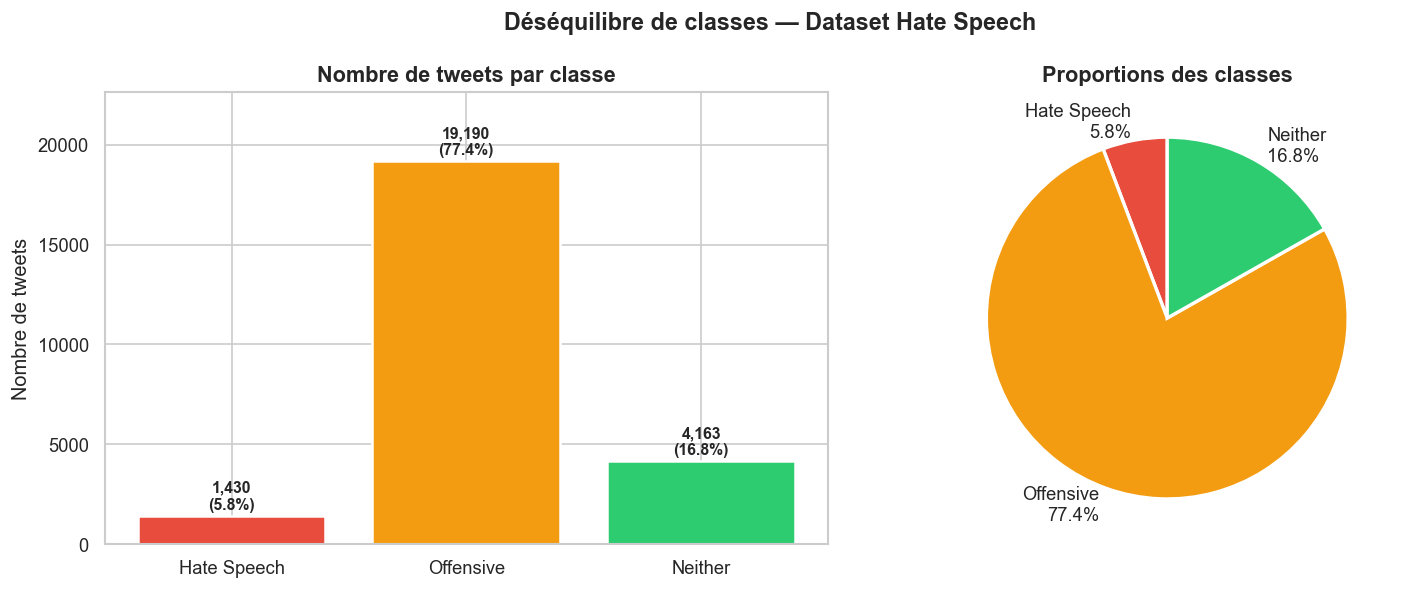

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ─── Barplot avec annotations
bars = axes[0].bar(ORDER, dist.values, color=[PALETTE[c] for c in ORDER], edgecolor='white', linewidth=1.5)
for b, n in zip(bars, dist.values):
    axes[0].text(b.get_x() + b.get_width()/2, n + 150,
                 f"{n:,}\n({n/len(df)*100:.1f}%)", ha='center', va='bottom', fontsize=9.5, fontweight='bold')
axes[0].set_title('Nombre de tweets par classe', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Nombre de tweets')
axes[0].set_ylim(0, dist.max() * 1.18)

# ─── Pie chart
axes[1].pie(
    dist.values,
    labels=[f"{c}\n{v/len(df)*100:.1f}%" for c, v in zip(ORDER, dist.values)],
    colors=[PALETTE[c] for c in ORDER],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 11}
)
axes[1].set_title('Proportions des classes', fontweight='bold', fontsize=13)

plt.suptitle('Déséquilibre de classes — Dataset Hate Speech', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_class_distribution.png', bbox_inches='tight', dpi=130)
plt.show()


<div style="background-color:#FCE4EC; padding:15px; border-left:6px solid #E91E63; border-radius:8px;">

<h3> Interprétation — Section 2</h3>

<ul>
<li>Le dataset est <b>sévèrement déséquilibré</b> : la classe <i>Offensive</i> domine avec ~<b>77,4 %</b> des tweets, tandis que <i>Hate Speech</i> — la classe d'intérêt principal — est la plus rare avec seulement ~<b>5,8 %</b> des données, soit un ratio de déséquilibre de <b>13 : 1</b>.</li>

<li><b>Implication métrique</b> : la précision brute (<i>accuracy</i>) est trompeuse — un classifieur naïf qui prédit toujours "Offensive" obtiendrait ~77 %. Il faut utiliser le <b>F1-score macro, la précision et le rappel par classe</b>, en particulier le rappel sur <i>Hate Speech</i>.</li>

<li><b>Implication d'entraînement</b> : il est impératif d'utiliser des <b>splits stratifiés</b>, une <b>pondération des classes</b> (<code>class_weight='balanced'</code>) ou des techniques de <b>rééchantillonnage</b> (SMOTE, over/under-sampling) pour éviter que le modèle sous-apprenne la classe minoritaire.</li>

</ul>

</div>

## 3. Accord des Annotateurs — Confiance des Labels

Chaque tweet porte la décomposition des votes entre les 3+ annotateurs. On définit un **ratio d'accord** :

$$\text{accord} = \frac{\max(\text{votes pour une catégorie})}{\text{nombre total de votes (count)}}$$

- Valeur = 1.0 → unanimité totale entre annotateurs
- Valeur basse → désaccord, ambiguïté du label → **bruit dans les données**


In [42]:
df['max_votes'] = df[['hate_speech', 'offensive_language', 'neither']].max(axis=1)
df['agreement'] = df['max_votes'] / df['count']

agr_tbl = df.groupby('label')['agreement'].agg(['mean', 'median', 'std']).reindex(ORDER).round(3)
agr_tbl['pct_unanime'] = (
    df[df['agreement'] == 1.0].groupby('label').size().reindex(ORDER)
    / dist * 100
).round(1)
print("=== Accord des annotateurs par classe ===")
print(agr_tbl.to_string())


=== Accord des annotateurs par classe ===
              mean  median    std  pct_unanime
label                                         
Hate Speech  0.728   0.667  0.131         18.4
Offensive    0.919   1.000  0.141         74.8
Neither      0.899   1.000  0.153         69.0


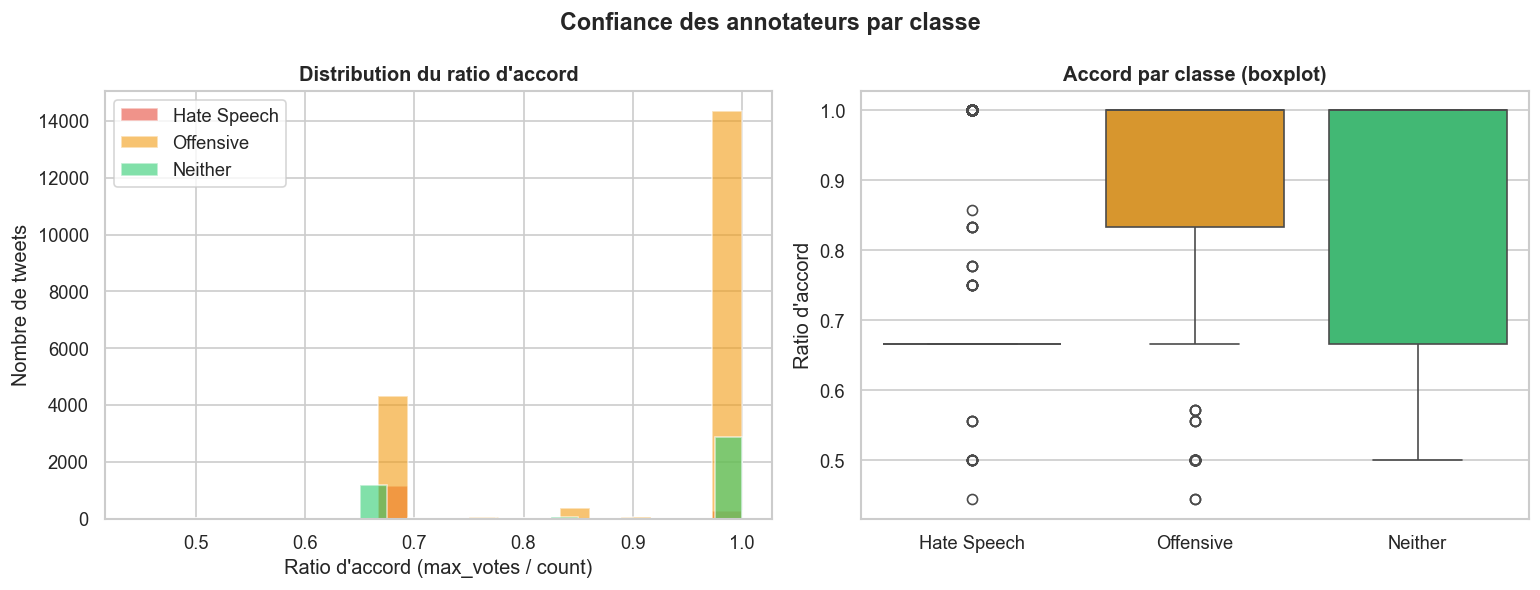

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ─── Histogramme
for c in ORDER:
    axes[0].hist(df[df['label'] == c]['agreement'], bins=20, alpha=0.6,
                 color=PALETTE[c], label=c, edgecolor='white')
axes[0].set_title('Distribution du ratio d\'accord', fontweight='bold')
axes[0].set_xlabel('Ratio d\'accord (max_votes / count)')
axes[0].set_ylabel('Nombre de tweets')
axes[0].legend()

# ─── Boxplot
sns.boxplot(data=df, x='label', y='agreement', order=ORDER,
            hue='label', palette=PALETTE, legend=False, ax=axes[1])
axes[1].set_title('Accord par classe (boxplot)', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Ratio d\'accord')

plt.suptitle('Confiance des annotateurs par classe', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_agreement.png', bbox_inches='tight', dpi=130)
plt.show()


<div style="background-color:#FCE4EC; padding:15px; border-left:6px solid #E91E63; border-radius:8px;">

<h3> Interprétation — Section 3</h3>

<ul>
<li><b>Offensive</b> (0.919) et <b>Neither</b> (0.899) présentent un accord très élevé, avec une médiane de 1.0 et une forte proportion d'annotations unanimes.</li>

<li><b>Hate Speech</b> affiche un accord nettement plus faible (0.728, médiane = 0.667, seulement 18.4 % d'unanimité), révélant une ambiguïté importante dans cette classe.</li>

<li>La distinction entre <i>Hate Speech</i> et <i>Offensive</i> semble donc difficile même pour les annotateurs humains, ce qui peut limiter les performances du modèle sur cette frontière de décision.</li>
</ul>

</div>

## 4. Corrélation entre Catégories de Votes

Les votes étant compositionnels (ils somment à `count`), les corrélations entre catégories révèlent quels types de contenu les annotateurs **confondent** entre eux.


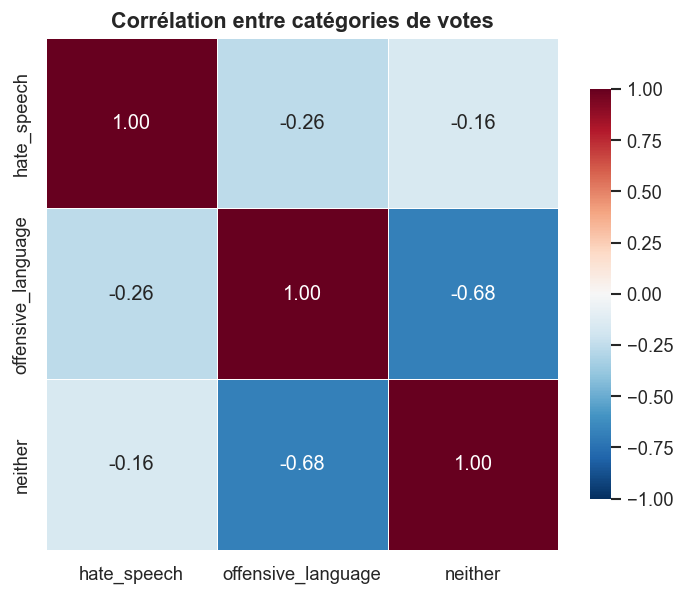

                    hate_speech  offensive_language  neither
hate_speech               1.000              -0.262   -0.158
offensive_language       -0.262               1.000   -0.684
neither                  -0.158              -0.684    1.000


In [44]:
vote_cols = ['hate_speech', 'offensive_language', 'neither']
corr = df[vote_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, linewidths=.5,
            cbar_kws={'shrink': .8}, ax=ax)
ax.set_title('Corrélation entre catégories de votes', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('fig_vote_corr.png', bbox_inches='tight', dpi=130)
plt.show()
print(corr.round(3).to_string())


<div style="background-color:#FCE4EC; padding:15px; border-left:6px solid #E91E63; border-radius:8px;">

<h3> Interprétation — Section 4</h3>

<ul>
<li>Toutes les corrélations sont <b>négatives</b>, ce qui est attendu puisque les votes sont compositionnels : une augmentation des votes pour une catégorie réduit mécaniquement ceux des autres.</li>

<li>L'opposition la plus forte est observée entre <b>Offensive</b> et <b>Neither</b> (r = -0.684), indiquant que ces deux catégories représentent généralement des cas bien distincts.</li>

<li>La corrélation entre <b>Hate Speech</b> et <b>Offensive</b> est plus faible (r = -0.262) que celle entre <b>Offensive</b> et <b>Neither</b>, suggérant que les votes sont plus souvent répartis entre ces deux classes. Cette observation confirme l'ambiguïté déjà mise en évidence dans l'analyse de l'accord des annotateurs.</li>

<li><b>Implication :</b> la principale difficulté de classification devrait se situer à la frontière <i>Hate Speech ↔ Offensive</i>. Des approches hiérarchiques ou une détection préalable du contenu haineux pourraient être envisagées pour améliorer la robustesse du modèle.</li>
</ul>

</div>

## 5. Longueur des Tweets

On analyse la distribution de la longueur en **caractères** et en **mots/tokens** par classe, afin de déterminer si la longueur est un signal discriminant et de calibrer la troncature dans les modèles de séquences.


In [45]:
tokenizer_tw = TweetTokenizer(preserve_case=False, strip_handles=True, reduce_len=True)

df['char_len']    = df['tweet'].str.len()
df['word_count']  = df['tweet'].str.split().apply(len)
df['token_count'] = df['tweet'].apply(lambda x: len(tokenizer_tw.tokenize(str(x))))

len_tbl = df.groupby('label')[['char_len', 'word_count', 'token_count']].agg(
    ['mean', 'median', 'std']
).reindex(ORDER).round(2)
print(len_tbl.to_string())
print(f"\n95e percentile — char_len  : {df['char_len'].quantile(.95):.0f}")
print(f"95e percentile — word_count : {df['word_count'].quantile(.95):.0f}")
print(f"Longueur maximale (chars)   : {df['char_len'].max()}")


            char_len               word_count              token_count             
                mean median    std       mean median   std        mean median   std
label                                                                              
Hate Speech    84.66   82.0  40.57      13.91   13.5  7.04       14.95   15.0  8.19
Offensive      83.54   78.0  41.55      13.96   13.0  6.80       15.35   14.0  7.91
Neither        94.98   97.0  41.18      14.92   15.0  6.80       16.61   16.0  8.01

95e percentile — char_len  : 146
95e percentile — word_count : 26
Longueur maximale (chars)   : 756


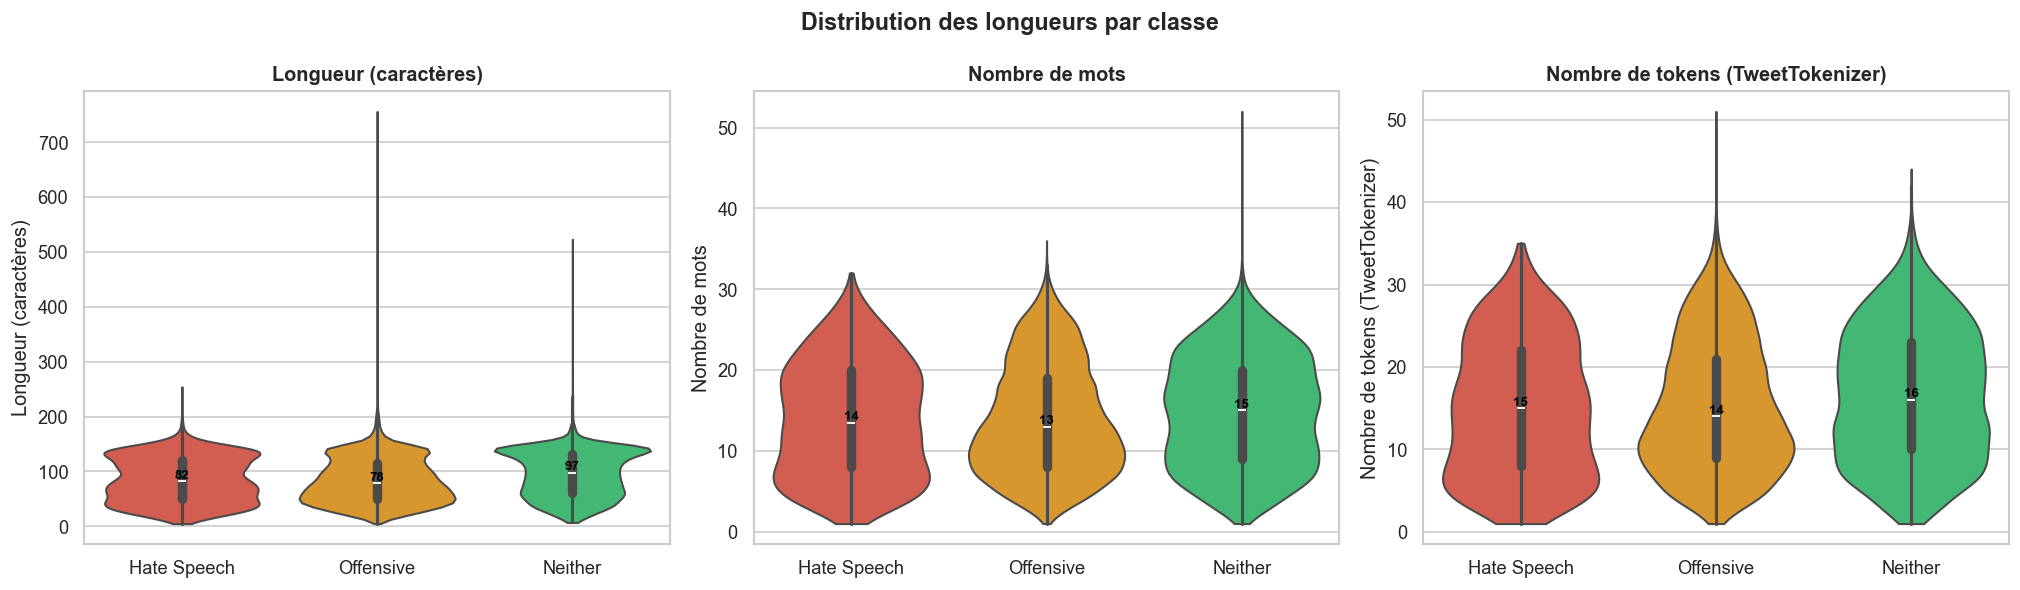

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
metrics = [
    ('char_len',    'Longueur (caractères)'),
    ('word_count',  'Nombre de mots'),
    ('token_count', 'Nombre de tokens (TweetTokenizer)'),
]

for ax, (col, title) in zip(axes, metrics):
    sns.violinplot(data=df, x='label', y=col, order=ORDER,
                   hue='label', palette=PALETTE, legend=False, cut=0, ax=ax)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel(title)
    # Ajouter la médiane comme annotation
    for i, c in enumerate(ORDER):
        med = df[df['label'] == c][col].median()
        ax.text(i, med, f'{med:.0f}', ha='center', va='bottom', fontsize=8,
                color='black', fontweight='bold')

plt.suptitle('Distribution des longueurs par classe', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_lengths.png', bbox_inches='tight', dpi=130)
plt.show()


<div style="background-color:#FCE4EC; padding:15px; border-left:6px solid #E91E63; border-radius:8px;">

<h3> Interprétation — Section 5</h3>

<ul>
<li>Les distributions de longueur sont <b>très proches entre les trois classes</b>. Les médianes varient seulement de 78 à 97 caractères et de 13 à 15 mots, ce qui indique que la longueur constitue un <b>signal discriminant faible</b>.</li>

<li>La classe <b>Neither</b> est légèrement plus longue en moyenne (95 caractères, 15 mots) que <i>Hate Speech</i> et <i>Offensive</i>, mais l'écart reste modeste au regard de la dispersion observée.</li>

<li>Le <b>95e percentile</b> se situe à environ <b>146 caractères</b> (≈ 26 mots), ce qui couvre la quasi-totalité des tweets du corpus.</li>

<li><b>Implication :</b> la longueur ne devrait pas être utilisée comme caractéristique principale de classification. Pour les modèles de séquences, une troncature comprise entre <b>128 et 256 tokens</b> est largement suffisante pour couvrir presque tous les exemples.</li>
</ul>

</div>

## 6. Diversité Lexicale (TTR)

On compare la richesse de vocabulaire entre classes via le **Type-Token Ratio (TTR)** = tokens uniques / tokens totaux. Le TTR brut est biaisé par la taille du corpus (une classe plus grande répète plus les mots). On calcule donc aussi un **TTR normalisé** sur des échantillons de taille égale.


In [47]:
token_re = re.compile(r"[a-z']+")

def tokenize_simple(text):
    return [t for t in token_re.findall(str(text).lower())
            if t not in STOP and len(t) > 2]

class_tokens = {
    c: [w for tw in df[df['label'] == c]['tweet'] for w in tokenize_simple(tw)]
    for c in ORDER
}

# TTR normalisé sur sous-échantillons de taille fixe
rng = np.random.default_rng(42)
sample_n = min(len(v) for v in class_tokens.values())

def normalized_ttr(tokens, n, draws=30):
    arr = np.array(tokens, dtype=object)
    return np.mean([len(set(rng.choice(arr, n, replace=False))) / n for _ in range(draws)])

rows = []
for c in ORDER:
    toks = class_tokens[c]
    rows.append({
        'total_tokens': len(toks),
        'vocab_size'  : len(set(toks)),
        'TTR_brut'    : round(len(set(toks)) / len(toks), 4),
        f'TTR_norm@{sample_n}': round(normalized_ttr(toks, sample_n), 4),
    })
lex_tbl = pd.DataFrame(rows, index=ORDER)
print(lex_tbl.to_string())


             total_tokens  vocab_size  TTR_brut  TTR_norm@11972
Hate Speech         11972        4705    0.3930          0.3930
Offensive          152403       26301    0.1726          0.3818
Neither             37203       13332    0.3584          0.4957


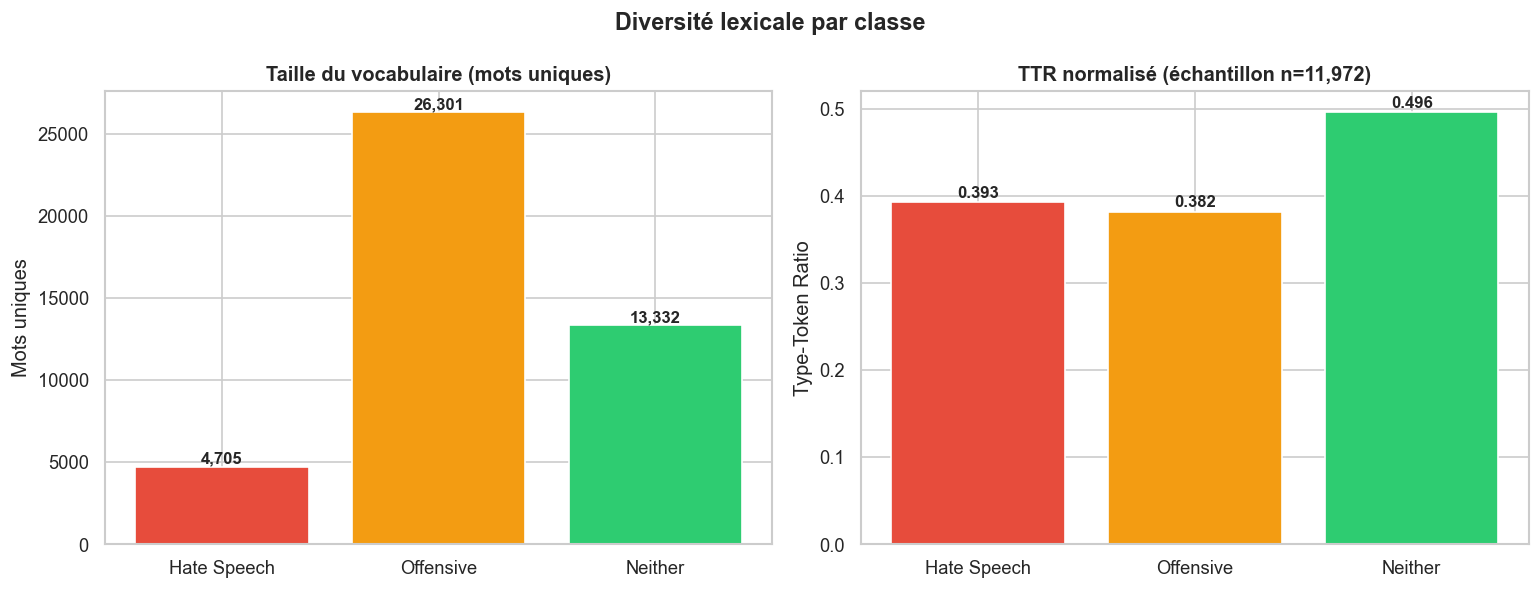

In [48]:
ntcol = [c for c in lex_tbl.columns if 'TTR_norm' in c][0]
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Taille du vocabulaire
axes[0].bar(ORDER, lex_tbl['vocab_size'], color=[PALETTE[c] for c in ORDER], edgecolor='white')
axes[0].set_title('Taille du vocabulaire (mots uniques)', fontweight='bold')
axes[0].set_ylabel('Mots uniques')
for i, v in enumerate(lex_tbl['vocab_size']):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# TTR normalisé
axes[1].bar(ORDER, lex_tbl[ntcol], color=[PALETTE[c] for c in ORDER], edgecolor='white')
axes[1].set_title(f'TTR normalisé (échantillon n={sample_n:,})', fontweight='bold')
axes[1].set_ylabel('Type-Token Ratio')
for i, v in enumerate(lex_tbl[ntcol]):
    axes[1].text(i, v + 0.002, f'{v:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('Diversité lexicale par classe', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_lexical_diversity.png', bbox_inches='tight', dpi=130)
plt.show()


<div style="background-color:#FCE4EC; padding:15px; border-left:6px solid #E91E63; border-radius:8px;">

<h3> Interprétation — Section 6</h3>

<ul>
<li>Le <b>TTR brut</b> est fortement influencé par la taille des corpus : la classe <i>Offensive</i> possède le plus grand vocabulaire absolu (26 301 mots uniques), mais aussi le corpus le plus volumineux, ce qui réduit mécaniquement son TTR brut.</li>

<li>Après <b>normalisation sur des échantillons de même taille</b>, <i>Neither</i> présente la plus forte diversité lexicale (TTR = 0.496), tandis que <i>Offensive</i> reste la classe la plus répétitive (TTR = 0.382).</li>

<li>La classe <i>Hate Speech</i> affiche une diversité intermédiaire (TTR = 0.393), proche de celle de <i>Offensive</i>, ce qui suggère que ces deux catégories reposent davantage sur un ensemble limité de termes récurrents que la classe <i>Neither</i>.</li>

<li><b>Implication :</b> les contenus offensifs semblent utiliser un vocabulaire relativement concentré et répétitif, alors que les tweets de la classe <i>Neither</i> couvrent des sujets plus variés et mobilisent un lexique plus riche.</li>
</ul>

</div>

## 7. Tokens de Surface & Signaux de Prétraitement

Les tweets contiennent des éléments non-linguistiques qui doivent être traités lors du prétraitement : **mentions (@user), hashtags (#tag), URLs, marqueurs de retweet (RT), entités HTML (&amp;)** et **emojis**. On quantifie leur présence globale et par classe.


In [49]:
surf_patterns = {
    'mention'    : r'@\w+',
    'hashtag'    : r'#\w+',
    'url'        : r'https?://\S+|www\.\S+',
    'retweet_RT' : r'\bRT\b',
    'html_entity': r'&\w+;|&#\d+;',
}
emoji_re = re.compile('[\U0001F000-\U0001FAFF\U00002600-\U000027BF'
                       '\U00002B00-\U00002BFF\U0001F1E6-\U0001F1FF]')

for name, pat in surf_patterns.items():
    df[f'has_{name}'] = df['tweet'].str.contains(pat, regex=True)
df['has_emoji'] = df['tweet'].apply(lambda t: bool(emoji_re.search(str(t))))

elements = list(surf_patterns.keys()) + ['emoji']
overall  = pd.Series({e: df[f'has_{e}'].mean() * 100 for e in elements}).round(2)
per_cls  = pd.DataFrame({
    e: df.groupby('label')[f'has_{e}'].mean() * 100 for e in elements
}).reindex(ORDER).round(2)

print("=== % de tweets contenant chaque élément (global) ===")
print(overall.to_string())
print("\n=== % par classe ===")
print(per_cls.to_string())


=== % de tweets contenant chaque élément (global) ===
mention        57.25
hashtag        30.80
url            12.04
retweet_RT     28.81
html_entity    26.76
emoji           0.00

=== % par classe ===
             mention  hashtag    url  retweet_RT  html_entity  emoji
label                                                               
Hate Speech    64.13    22.94   8.74       20.63        17.69    0.0
Offensive      56.00    29.98  10.05       29.16        27.55    0.0
Neither        60.68    37.28  22.36       29.98        26.26    0.0


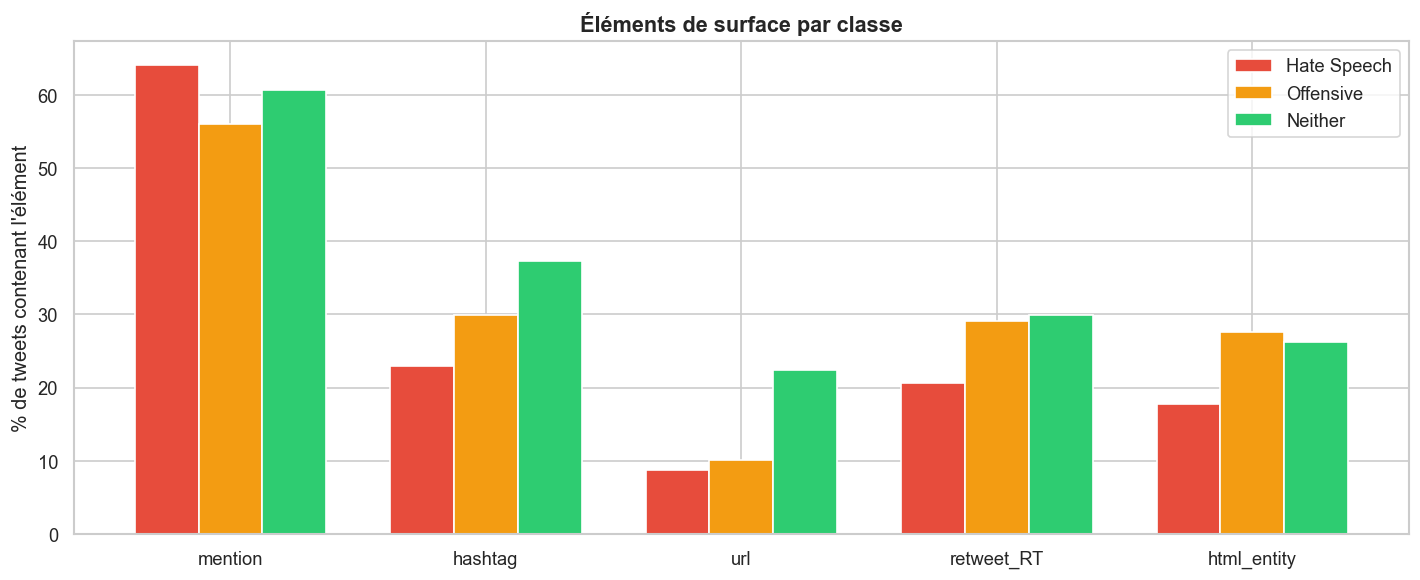

In [50]:
present = [e for e in elements if overall[e] > 0.5]  # exclure emoji (absent)
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(present))
w = 0.25

for i, c in enumerate(ORDER):
    ax.bar(x + (i-1)*w, per_cls.loc[c, present].values,
           width=w, color=PALETTE[c], edgecolor='white', label=c)

ax.set_xticks(x)
ax.set_xticklabels(present, fontsize=11)
ax.set_ylabel('% de tweets contenant l\'élément')
ax.set_title('Éléments de surface par classe', fontweight='bold', fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig('fig_surface_tokens.png', bbox_inches='tight', dpi=130)
plt.show()


<div style="background-color:#FCE4EC; padding:15px; border-left:6px solid #E91E63; border-radius:8px;">

<h3> Interprétation — Section 7</h3>

<ul>
<li>Les <b>mentions (@user)</b> sont très fréquentes dans le corpus (57.3 % des tweets) et apparaissent davantage dans <i>Hate Speech</i> (64.1 %), ce qui suggère que ces messages ciblent plus souvent des individus ou des groupes spécifiques.</li>

<li>Les <b>URLs</b> et <b>hashtags</b> sont nettement plus présents dans la classe <i>Neither</i> (22.4 % et 37.3 %), indiquant un usage plus fréquent de contenus informatifs, de partages de liens ou de discussions générales.</li>

<li>Les marqueurs de <b>retweet (RT)</b> apparaissent dans près de 29 % des tweets, tandis que les <b>entités HTML</b> concernent environ 27 % du corpus, ce qui justifie leur traitement lors du prétraitement.</li>

<li>Les <b>emojis sont absents</b> du dataset (0 %), ce qui indique qu'aucune stratégie spécifique de normalisation ou d'extraction d'emojis n'est nécessaire.</li>

<li><b>Implication :</b> la normalisation des mentions, URLs, entités HTML et marqueurs RT permettra de réduire la sparsité du vocabulaire tout en conservant l'information pertinente pour la classification.</li>
</ul>

</div>

## 8. Vocabulaire — Top Mots par Classe

On analyse les mots les plus fréquents dans chaque classe après suppression des stopwords, URLs, mentions et hashtags. Cela révèle les **patterns lexicaux distinctifs** de chaque catégorie.


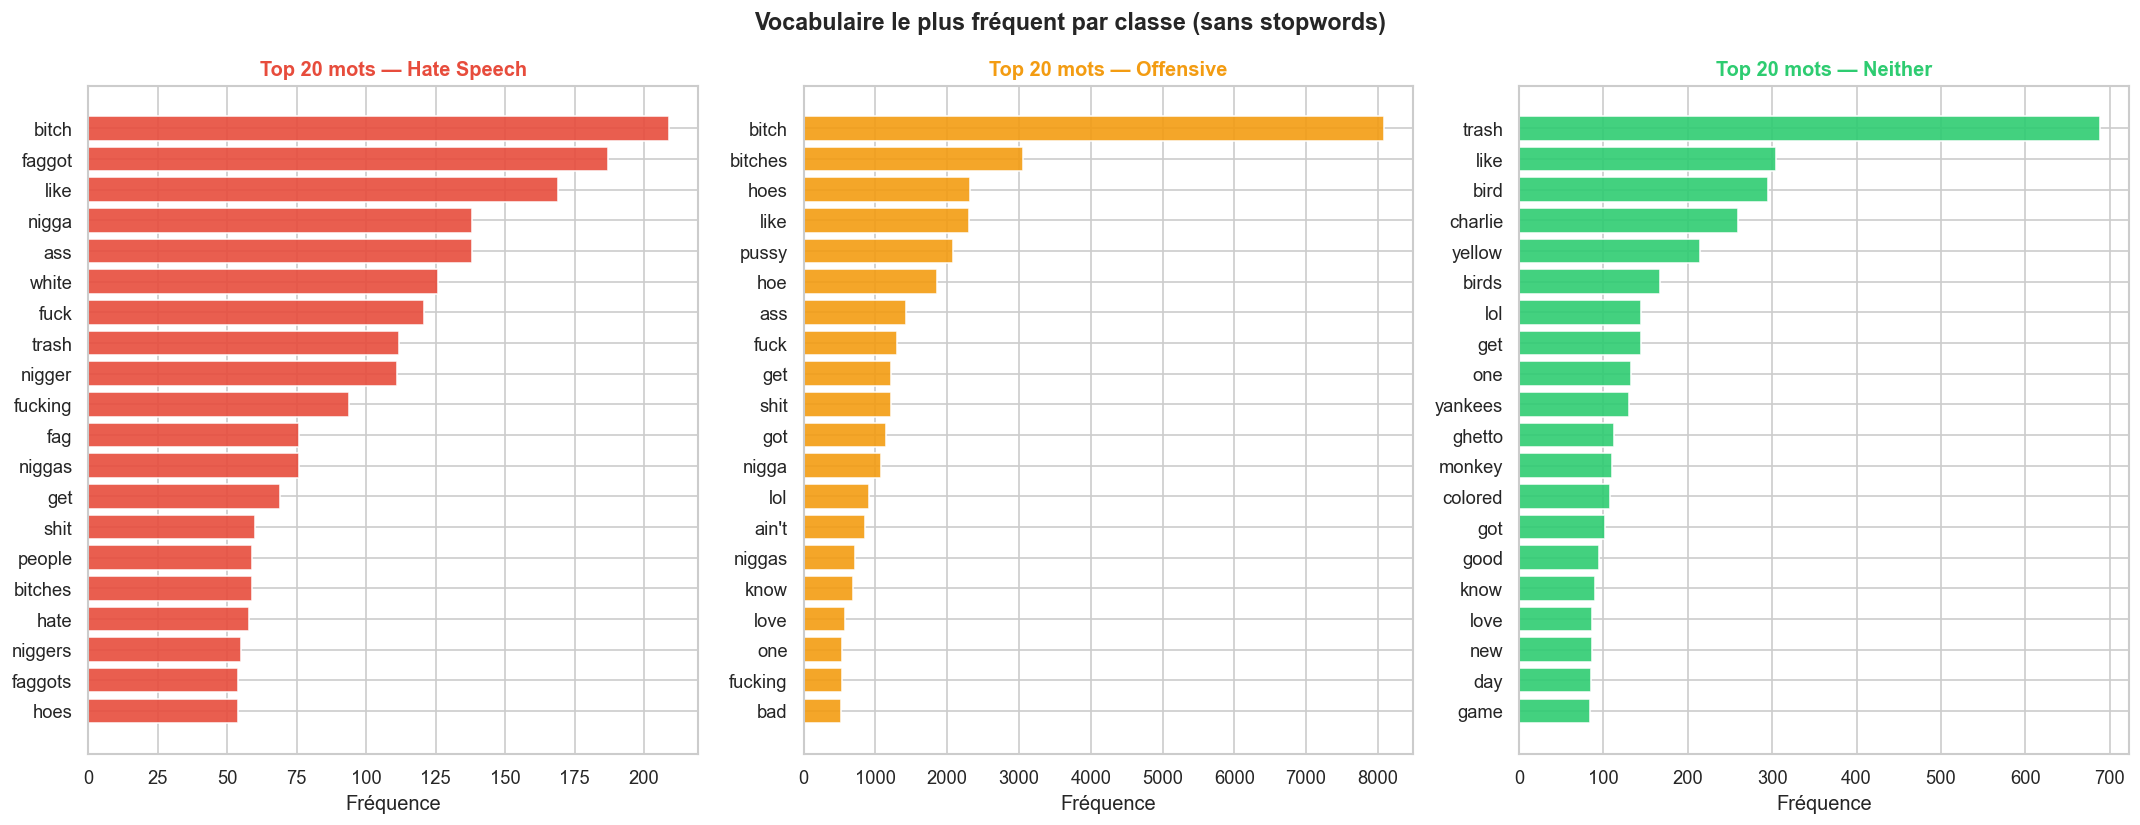

In [51]:
tw_tok = TweetTokenizer(preserve_case=False, strip_handles=True, reduce_len=True)

def get_top_words(class_label, n=25):
    texts = df[df['label'] == class_label]['tweet'].dropna()
    words = []
    for tweet in texts:
        tokens = tw_tok.tokenize(str(tweet))
        words.extend([
            t for t in tokens
            if t not in STOP
            and len(t) > 2
            and not re.match(r'^[\d\W]+$', t)
            and not t.startswith('http')
            and not t.startswith('#')
        ])
    return Counter(words).most_common(n)

top_words = {c: get_top_words(c) for c in ORDER}

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
for ax, c in zip(axes, ORDER):
    words, freqs = zip(*top_words[c][:20])
    ax.barh(list(reversed(words)), list(reversed(freqs)),
            color=PALETTE[c], edgecolor='white', alpha=0.9)
    ax.set_title(f'Top 20 mots — {c}', fontweight='bold', color=PALETTE[c], fontsize=12)
    ax.set_xlabel('Fréquence')

plt.suptitle('Vocabulaire le plus fréquent par classe (sans stopwords)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_top_words.png', bbox_inches='tight', dpi=130)
plt.show()


In [52]:
for c in ORDER:
    print(f"\n===== {c} =====")
    for word, freq in top_words[c]:
        print(f"{word:<20} {freq}")


===== Hate Speech =====
bitch                209
faggot               187
like                 169
nigga                138
ass                  138
white                126
fuck                 121
trash                112
nigger               111
fucking              94
fag                  76
niggas               76
get                  69
shit                 60
people               59
bitches              59
hate                 58
niggers              55
faggots              54
hoes                 54
pussy                49
lol                  49
got                  48
hoe                  42
look                 39

===== Offensive =====
bitch                8090
bitches              3049
hoes                 2322
like                 2308
pussy                2081
hoe                  1857
ass                  1431
fuck                 1302
get                  1220
shit                 1216
got                  1140
nigga                1078
lol                  907
ain't 

<div style="background-color:#FCE4EC; padding:15px; border-left:6px solid #E91E63; border-radius:8px;">

<h3>Interprétation — Section 8</h3>

<ul>

<li>
🔴 <b>Hate Speech</b> : le vocabulaire est marqué par la présence de nombreux <i>slurs</i> raciaux et homophobes (<i>nigger</i>, <i>faggot</i>, <i>fag</i>, <i>niggers</i>, <i>faggots</i>). Le terme <i>white</i> apparaît également parmi les mots les plus fréquents, suggérant que les références identitaires et raciales jouent un rôle important dans cette classe. Les fréquences restent relativement faibles en raison de la taille réduite du corpus.
</li>



<li>
🟠 <b>Offensive</b> : cette classe partage une partie de son vocabulaire avec <i>Hate Speech</i>, mais elle est dominée par des insultes et vulgarités génériques (<i>bitch</i>, <i>hoes</i>, <i>pussy</i>, <i>ass</i>, <i>fuck</i>). On observe également de nombreux termes conversationnels courants (<i>lol</i>, <i>love</i>, <i>know</i>, <i>want</i>), ce qui suggère que beaucoup de tweets sont offensants par leur ton plutôt que par un contenu explicitement haineux.
</li>



<li>
🟢 <b>Neither</b> : le vocabulaire est plus diversifié et davantage lié à des sujets spécifiques ou à l'actualité (<i>yankees</i>, <i>bird</i>, <i>game</i>, <i>day</i>, <i>new</i>). Certains termes potentiellement sensibles (<i>monkey</i>, <i>ghetto</i>, <i>colored</i>) apparaissent néanmoins dans cette classe, montrant que certains mots ne sont pas intrinsèquement haineux et que leur interprétation dépend fortement du contexte.
</li>



<li>
<b>Implication :</b> plusieurs mots sont partagés entre les classes (<i>bitch</i>, <i>nigga</i>, <i>trash</i>, <i>people</i>), ce qui indique que la classification ne peut pas reposer uniquement sur la présence de mots-clés. La prise en compte du contexte et des relations entre les mots sera essentielle pour distinguer correctement <i>Hate Speech</i>, <i>Offensive</i> et <i>Neither</i>.
</li>

</ul>

</div>

## 9. Word Clouds — Visualisation du Vocabulaire

*(Nécessite la librairie `wordcloud` — `pip install wordcloud`)*


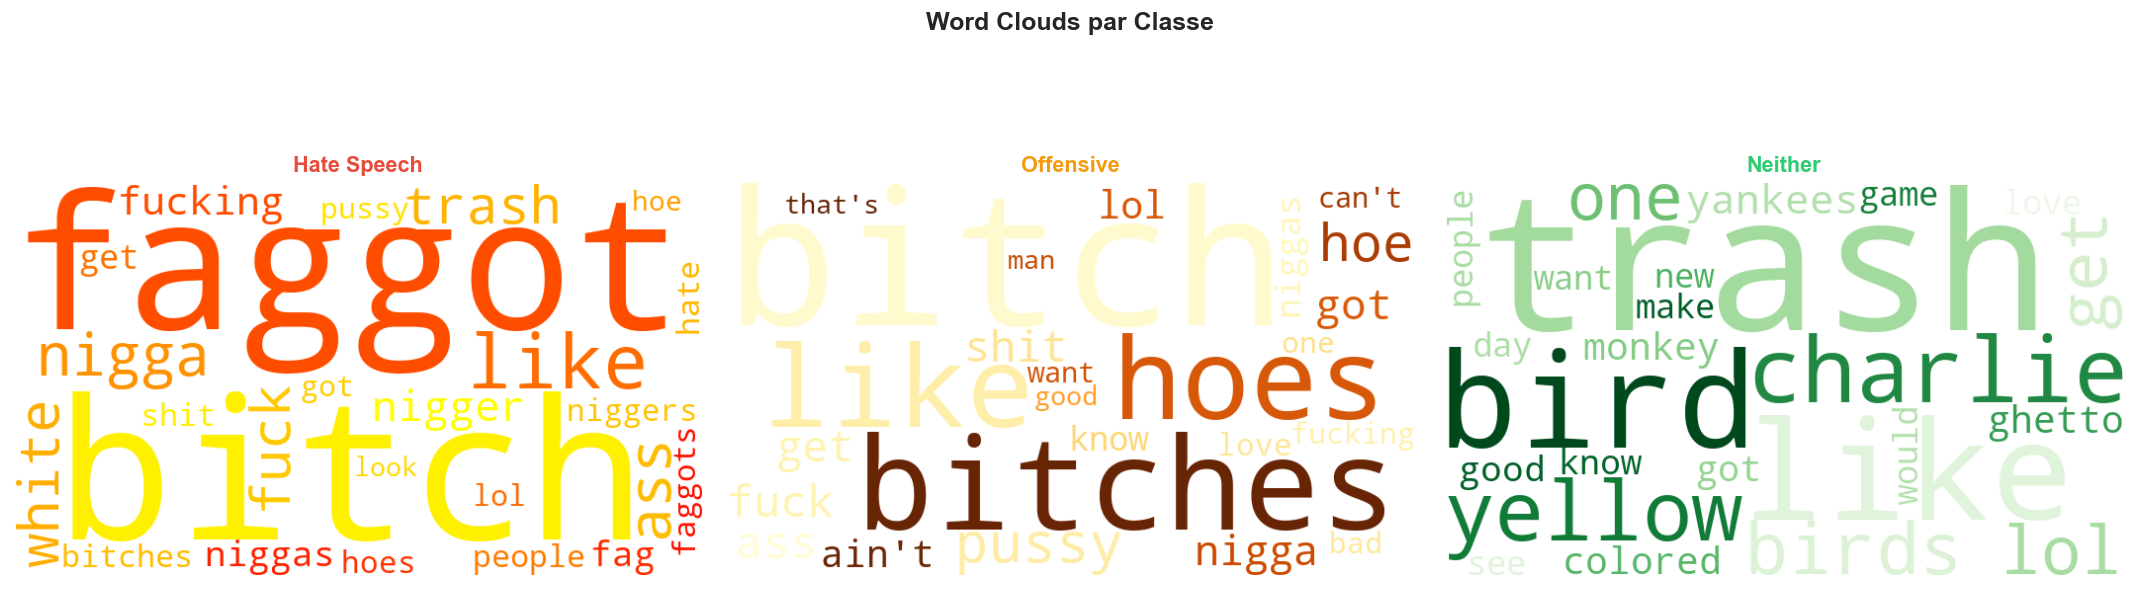

In [53]:
if WC_AVAILABLE:
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    for ax, c in zip(axes, ORDER):
        words = ' '.join(w for w, _ in top_words[c])
        color = PALETTE[c].lstrip('#')
        r, g, b = int(color[:2],16), int(color[2:4],16), int(color[4:],16)

        wc = WordCloud(
            width=700, height=400,
            background_color='white',
            colormap='autumn' if c=='Hate Speech' else ('YlOrBr' if c=='Offensive' else 'Greens'),
            max_words=80,
            prefer_horizontal=0.9
        ).generate_from_frequencies(dict(top_words[c]))

        ax.imshow(wc, interpolation='bilinear')
        ax.axis('off')
        ax.set_title(c, fontweight='bold', color=PALETTE[c], fontsize=13)

    plt.suptitle('Word Clouds par Classe', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.savefig('fig_wordclouds.png', bbox_inches='tight', dpi=130)
    plt.show()
else:
    print("wordcloud non disponible — installez-le avec : pip install wordcloud")


## 10. N-grammes Caractéristiques par Classe

Les bigrammes et trigrammes capturent des **patterns linguistiques contextuels** que les unigrammes seuls ne peuvent pas révéler (ex : "white people", "kill yourself").


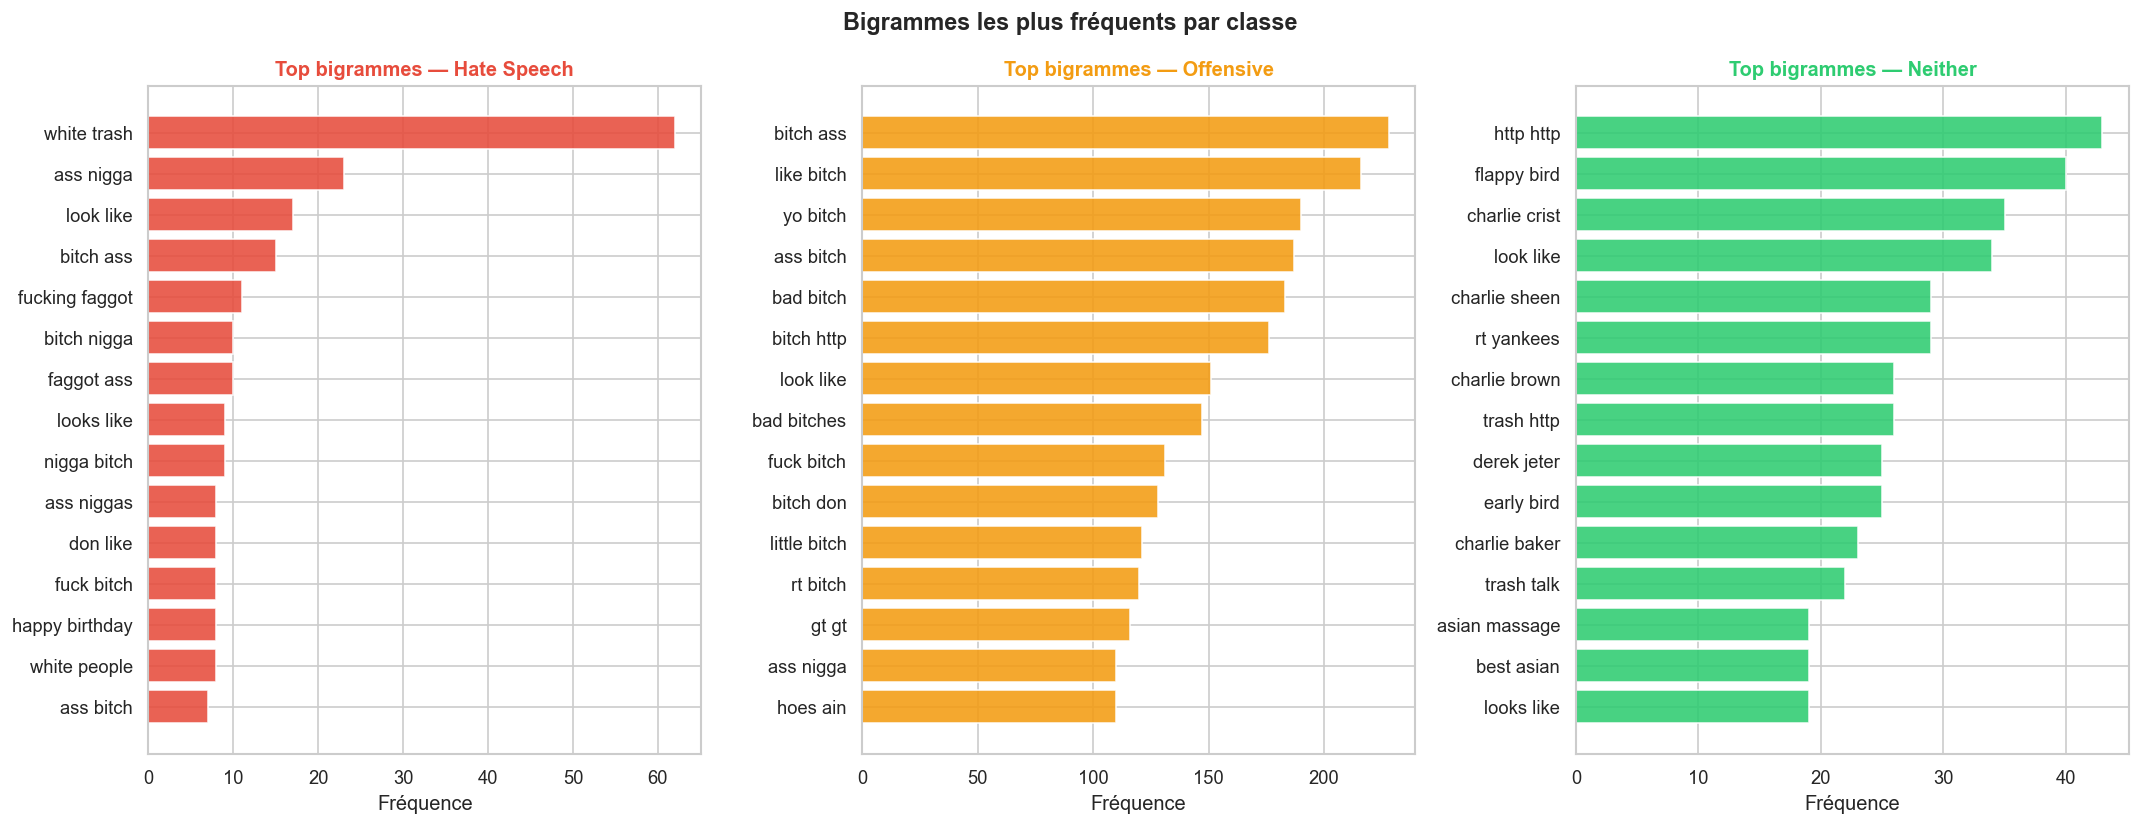

In [54]:
def get_top_ngrams(class_label, ngram_range=(2,2), top_n=15):
    texts = df[df['label'] == class_label]['tweet'].fillna('').tolist()
    vec = CountVectorizer(
        ngram_range=ngram_range,
        stop_words='english',
        min_df=2,
        max_features=8000,
        token_pattern=r'(?u)\b[a-zA-Z][a-zA-Z]+\b'
    )
    X = vec.fit_transform(texts)
    freqs = X.sum(axis=0).A1
    vocab = vec.get_feature_names_out()
    top = sorted(zip(vocab, freqs), key=lambda x: x[1], reverse=True)[:top_n]
    return top

# ─── Bigrammes
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
for ax, c in zip(axes, ORDER):
    top = get_top_ngrams(c, (2,2), 15)
    if top:
        ngrams, freqs = zip(*top)
        ax.barh(list(reversed(ngrams)), list(reversed(freqs)),
                color=PALETTE[c], edgecolor='white', alpha=0.88)
    ax.set_title(f'Top bigrammes — {c}', fontweight='bold', color=PALETTE[c])
    ax.set_xlabel('Fréquence')

plt.suptitle('Bigrammes les plus fréquents par classe', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_bigrams.png', bbox_inches='tight', dpi=130)
plt.show()


In [55]:
for c in ORDER:
    print(f"\n===== {c} =====")
    top = get_top_ngrams(c, (2,2), 15)

    for bg, freq in top:
        print(f"{bg:<30} {freq}")


===== Hate Speech =====
white trash                    62
ass nigga                      23
look like                      17
bitch ass                      15
fucking faggot                 11
bitch nigga                    10
faggot ass                     10
looks like                     9
nigga bitch                    9
ass niggas                     8
don like                       8
fuck bitch                     8
happy birthday                 8
white people                   8
ass bitch                      7

===== Offensive =====
bitch ass                      228
like bitch                     216
yo bitch                       190
ass bitch                      187
bad bitch                      183
bitch http                     176
look like                      151
bad bitches                    147
fuck bitch                     131
bitch don                      128
little bitch                   121
rt bitch                       120
gt gt                         

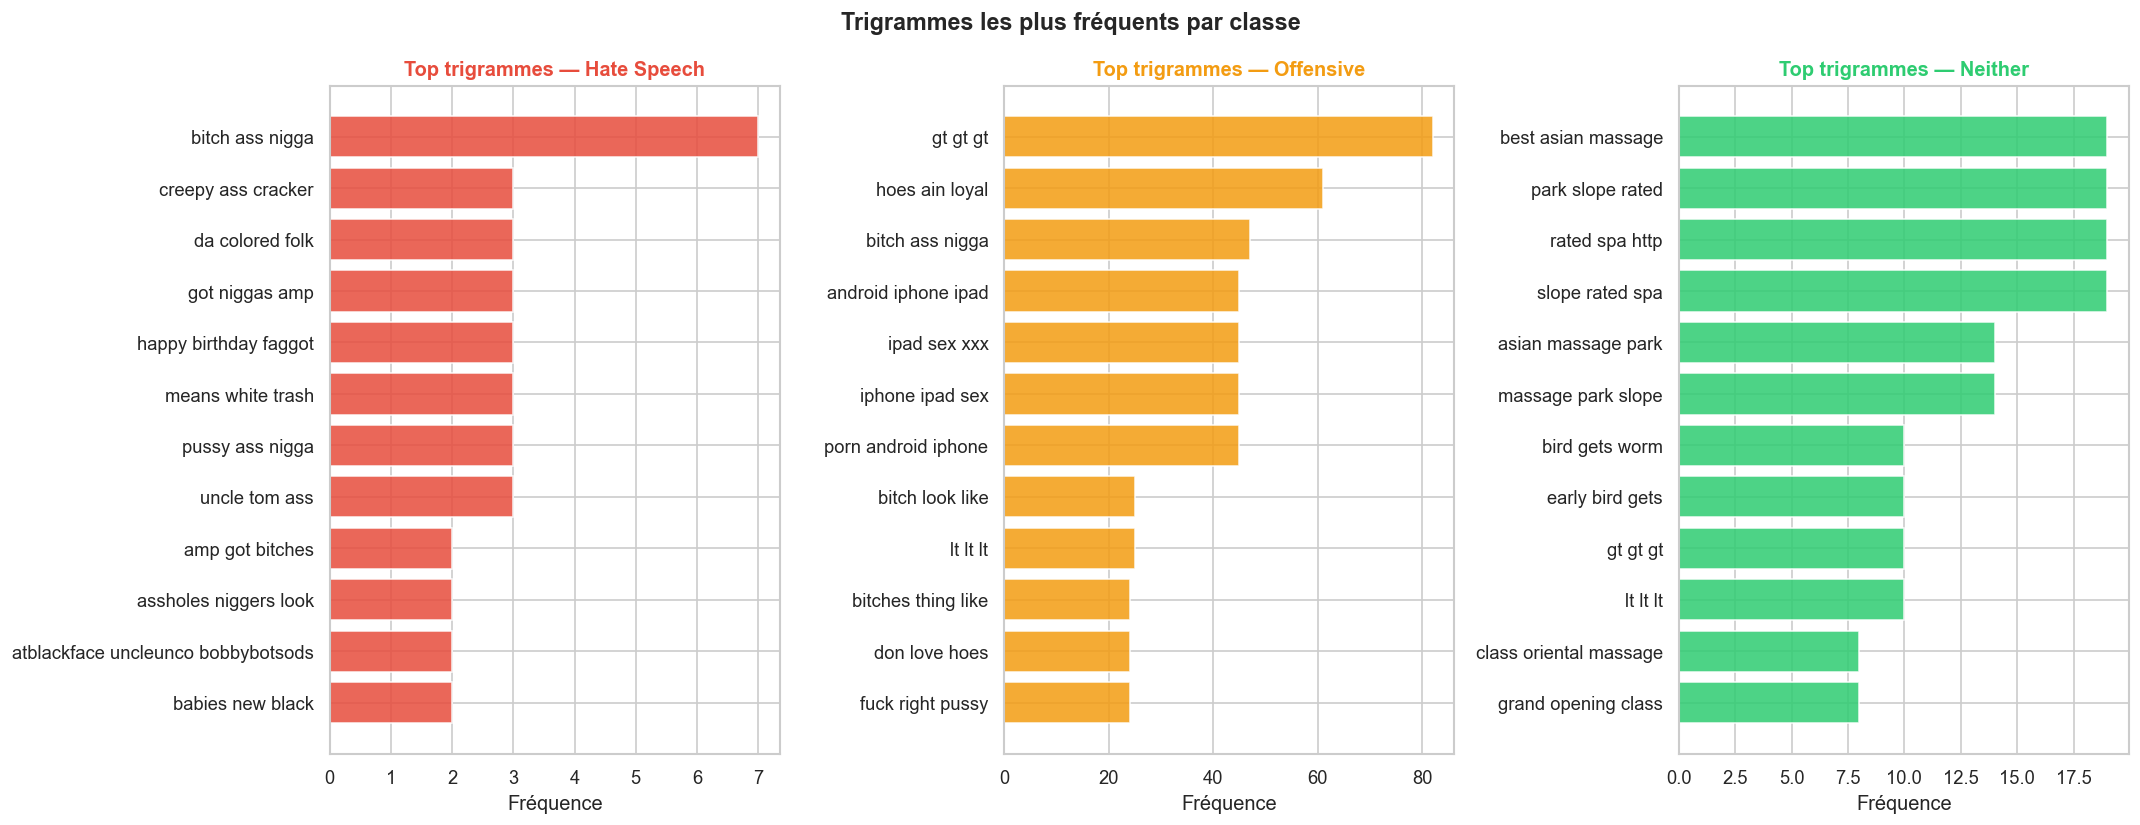

In [56]:
# ─── Trigrammes
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
for ax, c in zip(axes, ORDER):
    top = get_top_ngrams(c, (3,3), 12)
    if top:
        ngrams, freqs = zip(*top)
        ax.barh(list(reversed(ngrams)), list(reversed(freqs)),
                color=PALETTE[c], edgecolor='white', alpha=0.85)
    ax.set_title(f'Top trigrammes — {c}', fontweight='bold', color=PALETTE[c])
    ax.set_xlabel('Fréquence')

plt.suptitle('Trigrammes les plus fréquents par classe', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_trigrams.png', bbox_inches='tight', dpi=130)
plt.show()


In [57]:
for c in ORDER:
    print(f"\n===== {c} =====")

    top = get_top_ngrams(c, (3,3), 20)

    for trigram, freq in top:
        print(f"{trigram:<40} {freq}")


===== Hate Speech =====
bitch ass nigga                          7
creepy ass cracker                       3
da colored folk                          3
got niggas amp                           3
happy birthday faggot                    3
means white trash                        3
pussy ass nigga                          3
uncle tom ass                            3
amp got bitches                          2
assholes niggers look                    2
atblackface uncleunco bobbybotsods       2
babies new black                         2
bitch ass niggas                         2
bitch look like                          2
black ghetto trash                       2
california white trash                   2
cause look like                          2
coon ass nigga                           2
darling phil robertson                   2
don like duck                            2

===== Offensive =====
gt gt gt                                 82
hoes ain loyal                           61
bitc

<div style="background-color:#FCE4EC; padding:15px; border-left:6px solid #E91E63; border-radius:8px;">

<h3> Interprétation — Section 10</h3>

<ul>

<li>
🔴 <b>Hate Speech</b> : les bigrammes et trigrammes contiennent fréquemment des <i>slurs</i> raciaux ou homophobes (<i>white trash</i>, <i>fucking faggot</i>, <i>bitch ass nigga</i>, <i>coon ass nigga</i>). Contrairement à l'analyse par mots isolés, les n-grammes révèlent des expressions complètes de ciblage et d'insulte, fournissant davantage de contexte sur la nature du discours haineux.
</li>

<br>

<li>
🟠 <b>Offensive</b> : les expressions dominantes sont principalement des insultes génériques et de l'argot conversationnel (<i>bitch ass</i>, <i>yo bitch</i>, <i>bad bitch</i>, <i>stupid ass bitch</i>). Elles sont fortement répétées mais ciblent rarement une identité ou un groupe spécifique, ce qui les distingue des expressions observées dans <i>Hate Speech</i>.
</li>

<br>

<li>
🟢 <b>Neither</b> : les n-grammes sont davantage associés à des sujets thématiques ou informatifs (<i>flappy bird</i>, <i>new york yankees</i>, <i>charlie brown</i>, <i>early bird gets worm</i>). Leur présence confirme que cette classe couvre des discussions générales, du sport, de l'actualité ou du contenu promotionnel plutôt que des attaques directes.
</li>

<br>

<li>
<b>Implication :</b> les n-grammes apportent un contexte que les mots isolés ne capturent pas. Des expressions telles que <i>white trash</i>, <i>fucking faggot</i> ou <i>bitch ass nigga</i> sont potentiellement plus discriminantes pour la classification que les mots pris individuellement. L'utilisation de bigrammes et trigrammes dans les représentations TF-IDF peut donc améliorer la séparation entre les classes.
</li>

</ul>

</div>

## 11. Features Structurelles & Pragmatiques

On extrait et compare des features numériques de surface (ponctuation, majuscules, hashtags, mentions, URLs) pour évaluer leur pouvoir discriminant et leur corrélation avec la variable cible.


In [58]:
df['excl_count']     = df['tweet'].str.count(r'!')
df['question_count'] = df['tweet'].str.count(r'\?')
df['caps_ratio']     = df['tweet'].apply(
    lambda x: sum(1 for c in str(x) if c.isupper()) / max(len(str(x)), 1)
)
df['punct_count']    = df['tweet'].apply(lambda x: sum(1 for c in str(x) if c in string.punctuation))
df['hashtag_count']  = df['tweet'].str.count(r'#\w+')
df['mention_count']  = df['tweet'].str.count(r'@\w+')
df['url_count']      = df['tweet'].str.count(r'https?://\S+')

feat_cols = ['excl_count', 'question_count', 'caps_ratio', 'punct_count',
             'hashtag_count', 'mention_count', 'url_count']

print("Moyennes par classe :")
print(df.groupby('label')[feat_cols].mean().round(3).to_string())


Moyennes par classe :
             excl_count  question_count  caps_ratio  punct_count  hashtag_count  mention_count  url_count
label                                                                                                    
Hate Speech       0.177           0.122       0.058        5.285          0.483          0.944      0.088
Neither           0.202           0.124       0.073        7.020          0.817          0.845      0.240
Offensive         0.171           0.098       0.057        6.282          0.793          0.751      0.102


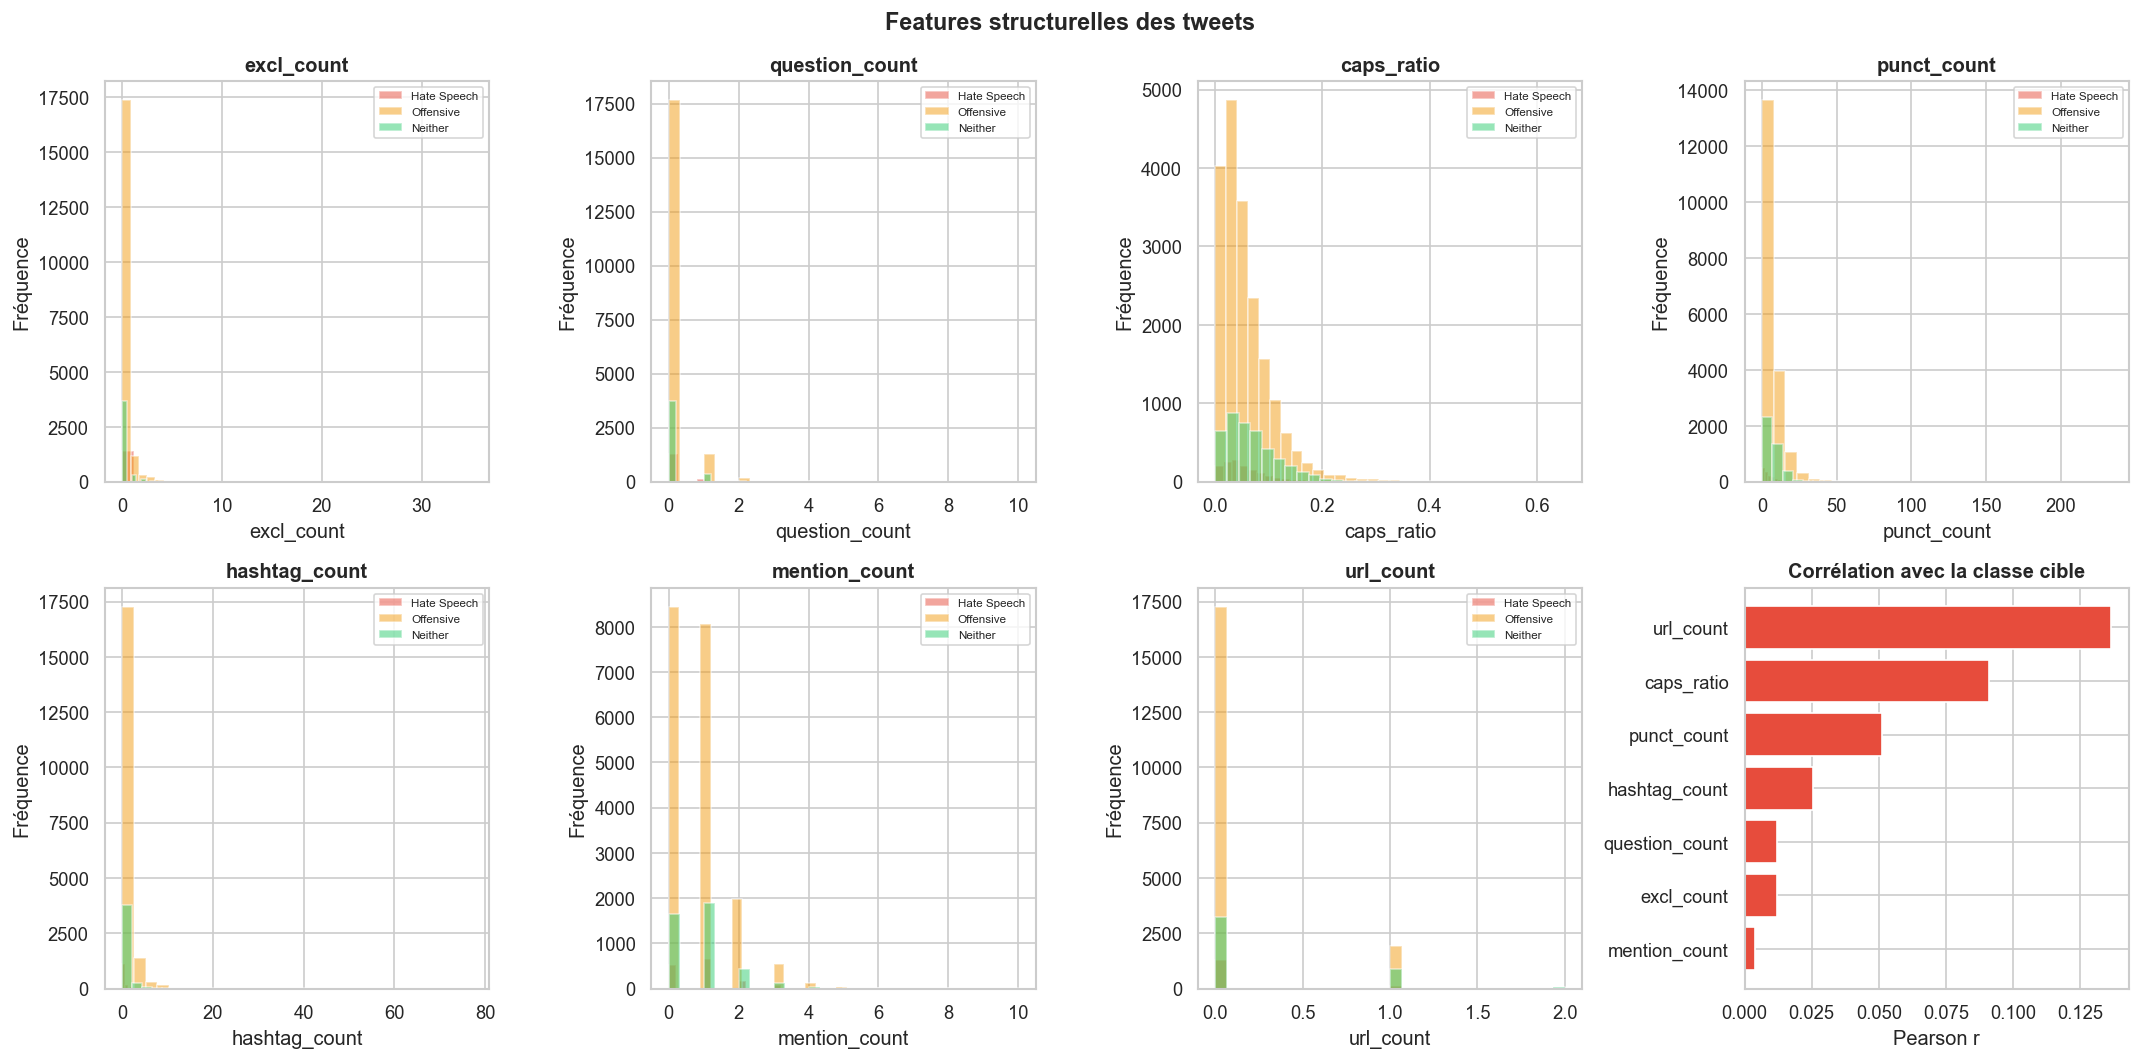

In [59]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for idx, col in enumerate(feat_cols):
    ax = axes[idx]
    for c in ORDER:
        subset = df[df['label'] == c][col]
        ax.hist(subset, bins=30, alpha=0.5, color=PALETTE[c], label=c, edgecolor='white')
    ax.set_title(col, fontweight='bold')
    ax.legend(fontsize=7)
    ax.set_xlabel(col)
    ax.set_ylabel('Fréquence')

# Heatmap de corrélation avec la classe
ax = axes[-1]
corr_cls = df[feat_cols + ['class']].corr()['class'].drop('class').sort_values()
colors_corr = ['#e74c3c' if v > 0 else '#3498db' for v in corr_cls.values]
ax.barh(corr_cls.index, corr_cls.values, color=colors_corr, edgecolor='white')
ax.axvline(0, color='black', linewidth=1)
ax.set_title('Corrélation avec la classe cible', fontweight='bold')
ax.set_xlabel('Pearson r')

plt.suptitle('Features structurelles des tweets', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_structural_features.png', bbox_inches='tight', dpi=130)
plt.show()


<div style="background-color:#FCE4EC; padding:15px; border-left:6px solid #E91E63; border-radius:8px;">

<h3> Interprétation — Section 11</h3>

<ul>

<li>Les <b>mentions</b> sont légèrement plus fréquentes dans <i>Hate Speech</i> (0.94 par tweet en moyenne) que dans <i>Offensive</i> (0.75), ce qui suggère une plus forte tendance à adresser directement les messages à des individus ou groupes spécifiques.</li>

<li>Les <b>hashtags</b> (0.82) et surtout les <b>URLs</b> (0.24) sont plus présents dans la classe <i>Neither</i>, ce qui confirme les observations précédentes sur la présence accrue de contenus informatifs, promotionnels ou liés à l'actualité.</li>

<li>La classe <i>Neither</i> présente également le plus grand nombre moyen de <b>signes de ponctuation</b> (7.02) ainsi que le ratio de <b>majuscules</b> le plus élevé (0.073), bien que les écarts avec les autres classes restent modestes.</li>

<li>Les différences observées entre classes demeurent relativement faibles. Ces caractéristiques structurelles apportent donc peu d'information lorsqu'elles sont utilisées seules, mais peuvent constituer des <b>features complémentaires</b> utiles lorsqu'elles sont combinées à des caractéristiques lexicales ou sémantiques.</li>

</ul>

</div>

## 12. Analyse des Termes Haineux & Dégradants

On catégorise les termes sensibles (slurs raciaux, termes sexistes, homophobes, etc.) et on mesure leur présence moyenne par classe — ce qui révèle la **spécificité de chaque type de discours**.


In [60]:
HATE_TERMS = {
    'slurs_raciaux' : [r'\bn[i1!]g+[ae]r?\b', r'\bn[i!1]gg[ae]\b', r'\bcoon\b', r'\bjigaboo\b'],
    'termes_sexistes': [r'\bb[i1!]tc[h]+\b', r'\bslut\b', r'\bwhore\b', r'\bcunt\b', r'\bthot\b'],
    'homophobie'    : [r'\bf[a@]gg?[o0]t\b', r'\bdyke\b', r'\bqueer\b'],
    'profanite'     : [r'\bf[u*]c?k\b', r'\bsh[i!1]t\b', r'\bdamn\b', r'\bass\b'],
    'violence'      : [r'\bkill\b', r'\bhate\b', r'\bdead\b', r'\bdie\b', r'\bshoot\b'],
    'deshumanisation': [r'\banimal\b', r'\bsavage\b', r'\bmonkey\b', r'\bape\b', r'\brat\b'],
}

def count_terms(text, patterns):
    text = str(text).lower()
    return sum(len(re.findall(p, text)) for p in patterns)

for category, patterns in HATE_TERMS.items():
    df[f'term_{category}'] = df['tweet'].apply(lambda x: count_terms(x, patterns))

term_cols = [f'term_{k}' for k in HATE_TERMS]
print("Présence moyenne par classe :")
print(df.groupby('label')[term_cols].mean().round(4).to_string())


Présence moyenne par classe :
             term_slurs_raciaux  term_termes_sexistes  term_homophobie  term_profanite  term_violence  term_deshumanisation
label                                                                                                                      
Hate Speech              0.2902                0.1713           0.1748          0.2350         0.0790                0.0147
Neither                  0.0038                0.0029           0.0026          0.0067         0.0219                0.0336
Offensive                0.1214                0.4423           0.0174          0.2234         0.0327                0.0040


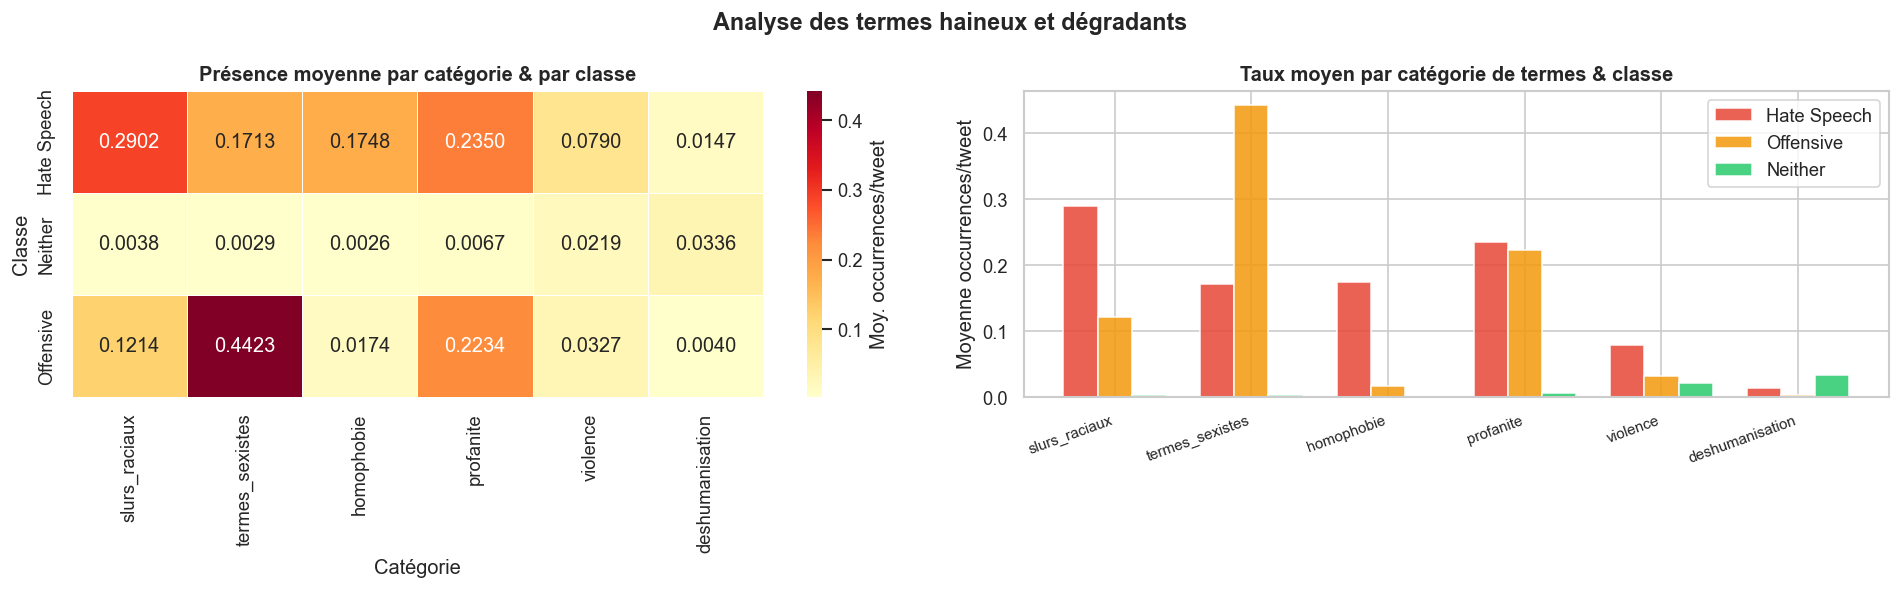

In [61]:
term_means = df.groupby('label')[term_cols].mean()
term_means.columns = list(HATE_TERMS.keys())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Heatmap
sns.heatmap(term_means, annot=True, fmt='.4f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Moy. occurrences/tweet'}, ax=axes[0])
axes[0].set_title('Présence moyenne par catégorie & par classe', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Catégorie')
axes[0].set_ylabel('Classe')

# Barplot groupé
x = np.arange(len(HATE_TERMS))
w = 0.25
for i, c in enumerate(ORDER):
    axes[1].bar(x + (i-1)*w, term_means.loc[c].values,
                width=w, color=PALETTE[c], edgecolor='white', label=c, alpha=0.88)
axes[1].set_xticks(x)
axes[1].set_xticklabels(list(HATE_TERMS.keys()), rotation=20, ha='right', fontsize=9)
axes[1].set_ylabel('Moyenne occurrences/tweet')
axes[1].set_title('Taux moyen par catégorie de termes & classe', fontweight='bold', fontsize=12)
axes[1].legend()

plt.suptitle('Analyse des termes haineux et dégradants', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_hate_terms.png', bbox_inches='tight', dpi=130)
plt.show()


<div style="background-color:#FCE4EC; padding:15px; border-left:6px solid #E91E63; border-radius:8px;">
<h3>Interprétation — Section 12</h3>
<ul>

<li><b>Slurs raciaux</b> : feature la plus discriminante — taux élevé dans <i>Hate Speech</i> (0.29) et modéré dans <i>Offensive</i> (0.12), souvent sous forme d'argot réapproprié.</li>

<li><b>Termes sexistes</b> : plus présents dans <i>Offensive</i> (0.44) que dans <i>Hate Speech</i> (0.17) — des termes comme <i>bitch</i> relèvent davantage de l'insulte générique que du ciblage identitaire.</li>

<li><b>Termes homophobes</b> : concentrés dans <i>Hate Speech</i> (0.17), quasi-absents ailleurs — bon marqueur de ciblage identitaire.</li>

<li><b>Profanité</b> : similaire dans <i>Hate Speech</i> (0.24) et <i>Offensive</i> (0.22) — ne discrimine pas bien les deux classes, usage majoritairement expressif.</li>

<li><b>Violence</b> : dominante dans <i>Hate Speech</i> (0.079) mais présente dans les autres classes — discriminance partielle due aux hyperboles courantes sur Twitter.</li>
<li><b>Déshumanisation</b> : score paradoxalement plus élevé dans <i>Neither</i> (0.034) que dans <i>Hate Speech</i> (0.015) — le lexique capte des faux positifs, un audit s'impose avant toute utilisation.</li>

<li><b>Implication :</b> la combinaison <b>slur racial + terme homophobe</b> constitue le signal le plus fiable du <i>Hate Speech</i>. La déshumanisation n'est pas encore exploitable en l'état.</li>

</ul>
</div>

## 13. Tweets Ambigus — Frontière Hate Speech / Offensive

On identifie les tweets pour lesquels les annotateurs étaient **partagés entre Hate Speech et Offensive**, ce qui représente les cas d'apprentissage les plus difficiles.


In [62]:
df['is_ambiguous'] = (
    (df['hate_speech'] >= 1) &
    (df['offensive_language'] >= 1) &
    (df['agreement'] < 0.7)
)

print(f"Nombre de tweets ambigus (accord < 0.7 avec votes HS et Off) : {df['is_ambiguous'].sum():,}")
print(f"\nRépartition des classes parmi les ambigus :")
print(df[df['is_ambiguous']]['label'].value_counts().to_string())
print(f"\n% des tweets HS qui sont ambigus : {df[df['label']=='Hate Speech']['is_ambiguous'].mean()*100:.1f}%")
print(f"% des tweets Offensive qui sont ambigus : {df[df['label']=='Offensive']['is_ambiguous'].mean()*100:.1f}%")


Nombre de tweets ambigus (accord < 0.7 avec votes HS et Off) : 4,037

Répartition des classes parmi les ambigus :
label
Offensive      2974
Hate Speech    1036
Neither          27

% des tweets HS qui sont ambigus : 72.4%
% des tweets Offensive qui sont ambigus : 15.5%


In [63]:
print("\n=== Exemples de tweets ambigus (accord < 0.7) ===")
ambiguous_sample = df[df['is_ambiguous']].sample(6, random_state=42)
for _, row in ambiguous_sample.iterrows():
    print(f"Classe finale : {row['label']}  | HS:{row['hate_speech']}  Off:{row['offensive_language']}  Neu:{row['neither']}")
    print(f"  → {str(row['tweet'])[:160]}")
    print()



=== Exemples de tweets ambigus (accord < 0.7) ===
Classe finale : Hate Speech  | HS:2  Off:1  Neu:0
  → RT @frankthetank215: There might be a couple cotton pickers on the spurs but they all play unselfish white man basketball

Classe finale : Offensive  | HS:1  Off:2  Neu:0
  → &#128514;&#128514;&#128514;&#128514;&#128514;&#128514;&#128514;&#128514;"@AlisaRenee: you a faggot if you eat pork chops."

Classe finale : Offensive  | HS:1  Off:2  Neu:0
  → I'll always remember feeling like I was no good. Like I couldn't do it for you like that whack bitch could.. &amp; it's all because you lied..

Classe finale : Offensive  | HS:1  Off:2  Neu:0
  → Pussy ass hoe niggas, I can't fuck wit y'all

Classe finale : Offensive  | HS:1  Off:2  Neu:0
  → RT @lamLilDurk: Black girls hoes cause they fuck niggas for money revenge and dumb shit like that

Classe finale : Offensive  | HS:1  Off:2  Neu:0
  → Lot of my peeps playing 2nite, G playing against the heat, my nig Louie playing against Rutgers, an

<div style="background-color:#FCE4EC; padding:15px; border-left:6px solid #E91E63; border-radius:8px;">
<h3>Interprétation — Section 13</h3>
<ul>

<li><b>Concentration de l'ambiguïté</b> : les 4 037 tweets ambigus se répartissent quasi-exclusivement entre <i>Offensive</i> (2 974) et <i>Hate Speech</i> (1 036), avec seulement 27 <i>Neither</i>. La frontière problématique est bien entre ces deux classes, pas avec <i>Neither</i>.</li>

<li><b>Hate Speech particulièrement touché</b> : 72.4% des tweets <i>Hate Speech</i> sont ambigus, contre seulement 15.5% pour <i>Offensive</i>. Le modèle devra donc apprendre à discriminer des exemples sur lesquels les annotateurs humains eux-mêmes divergent — ce qui constitue un plafond de performance réaliste à anticiper.</li

<li><b>Les exemples illustrent bien la difficulté</b> : un tweet contenant <i>cotton pickers</i> est classé <i>Hate Speech</i> à seulement 2 voix contre 1 ; des tweets avec <i>faggot</i> ou <i>niggas</i> basculent en <i>Offensive</i> selon le contexte conversationnel. Le sens dépend fortement du registre, du locuteur et de l'intention — éléments difficilement capturables par un modèle textuel seul.</li><br>

</ul>
</div>

## 14. Distribution des Votes par Catégorie

On visualise comment les votes humains se répartissent pour chaque catégorie — cela quantifie l'amplitude du désaccord.


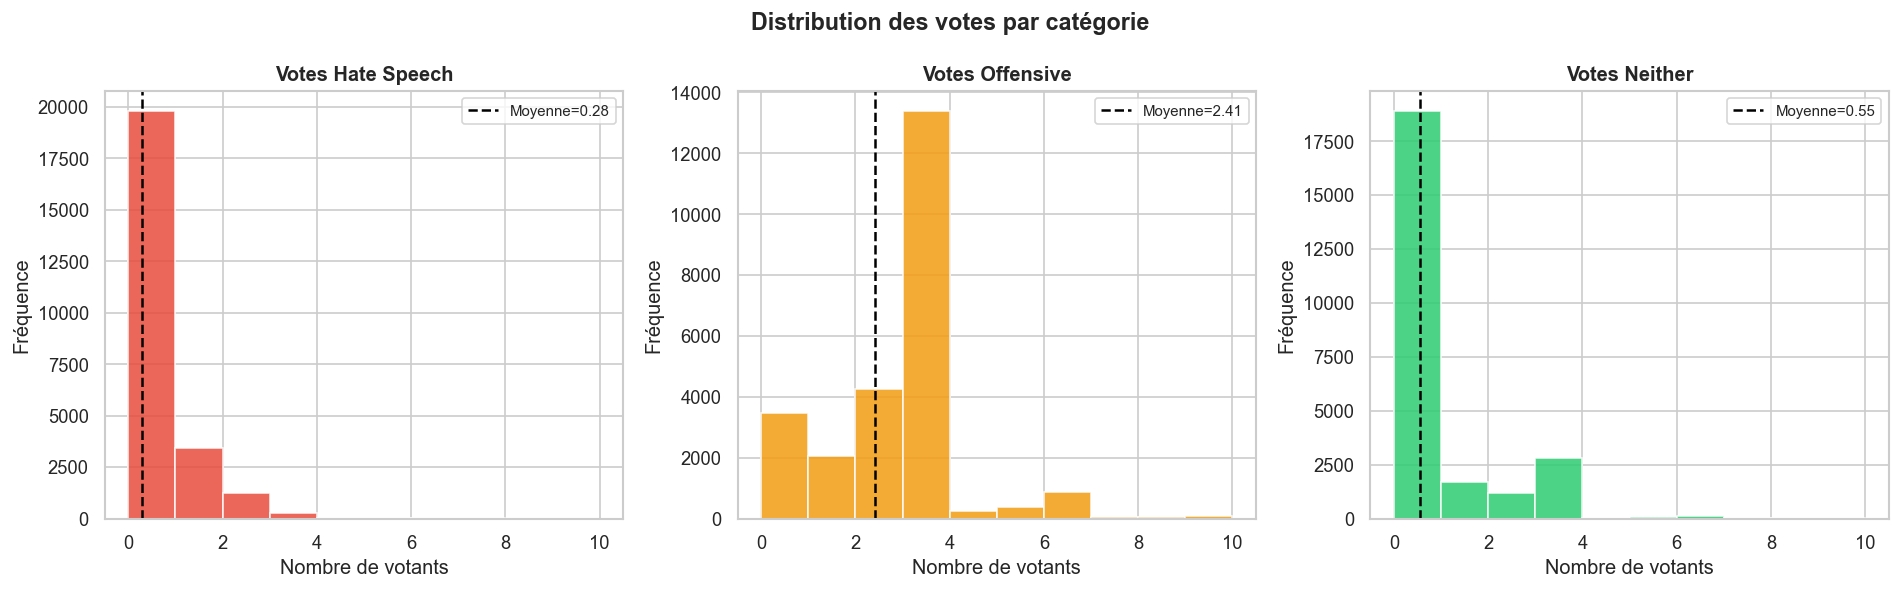

In [64]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (col, color, title) in zip(axes, [
    ('hate_speech',        '#e74c3c', 'Votes Hate Speech'),
    ('offensive_language', '#f39c12', 'Votes Offensive'),
    ('neither',            '#2ecc71', 'Votes Neither'),
]):
    ax.hist(df[col], bins=range(0, df['count'].max()+2),
            color=color, alpha=0.85, edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Nombre de votants')
    ax.set_ylabel('Fréquence')
    mean_val = df[col].mean()
    ax.axvline(mean_val, color='black', linestyle='--', linewidth=1.5,
               label=f'Moyenne={mean_val:.2f}')
    ax.legend(fontsize=9)

plt.suptitle('Distribution des votes par catégorie', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_votes_distribution.png', bbox_inches='tight', dpi=130)
plt.show()


<div style="background-color:#FCE4EC; padding:15px; border-left:6px solid #E91E63; border-radius:8px;">
<h3>Interprétation — Section 14</h3>
<ul>

<li><b>Votes Hate Speech</b> : distribution très concentrée sur 0 (≈20 000 tweets), moyenne de 0.28 — la quasi-totalité des tweets ne reçoit aucun vote haineux, confirmant la rareté et la difficulté d'identification de cette classe.</li><br>

<li><b>Votes Offensive</b> : distribution centrée sur 2-3 votes avec un pic à 3, moyenne de 2.41 — c'est la catégorie avec le consensus le plus élevé parmi les annotateurs, reflétant une reconnaissance plus intuitive du contenu offensif.</li><br>

<li><b>Votes Neither</b> : pic dominant à 0, avec une légère remontée autour de 3-4 — les tweets neutres sont soit ignorés dans cette catégorie (car jugés offensifs ou haineux), soit reconnus unanimement comme neutres par plusieurs annotateurs. La distribution n'est pas bimodale mais asymétrique à droite.</li><br>

<li><b>Implication :</b> la forte concentration des votes <i>Hate Speech</i> sur 0 justifie l'utilisation du ratio d'accord comme poids d'entraînement — les rares tweets avec 2+ votes HS constituent les exemples les plus fiables pour cette classe.</li>

</ul>
</div>

## 15. Matrice de Corrélation — Features Numériques

On visualise les corrélations entre toutes les features numériques calculées et la variable cible `class`, pour identifier les **signaux les plus exploitables** par un modèle de machine learning.


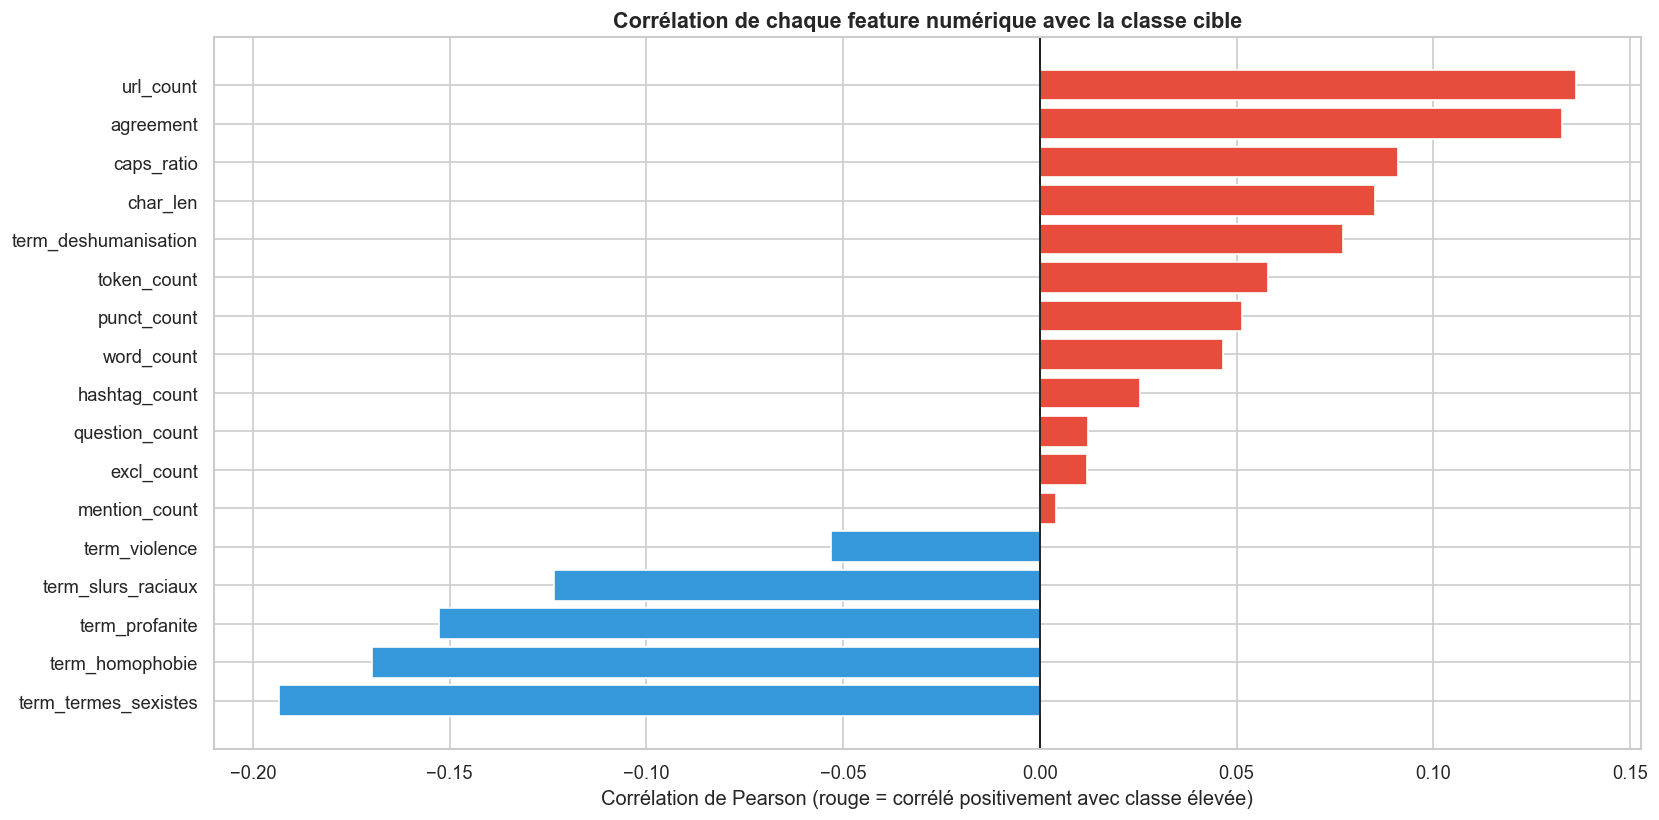


→ Top 5 features positivement corrélées avec la classe :
url_count               0.136241
agreement               0.132799
caps_ratio              0.090977
char_len                0.085122
term_deshumanisation    0.077071

→ Top 5 features négativement corrélées :
term_violence          -0.053197
term_slurs_raciaux     -0.123543
term_profanite         -0.152803
term_homophobie        -0.169798
term_termes_sexistes   -0.193460


In [65]:
all_feat_cols = [
    'char_len', 'word_count', 'token_count',
    'excl_count', 'question_count', 'caps_ratio', 'punct_count',
    'hashtag_count', 'mention_count', 'url_count',
    'agreement',
] + term_cols

corr_with_class = df[all_feat_cols + ['class']].corr()['class'].drop('class').sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 7))
colors_c = ['#e74c3c' if v > 0 else '#3498db' for v in corr_with_class.values]
ax.barh(corr_with_class.index, corr_with_class.values, color=colors_c, edgecolor='white')
ax.axvline(0, color='black', linewidth=1)
ax.set_title('Corrélation de chaque feature numérique avec la classe cible',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Corrélation de Pearson (rouge = corrélé positivement avec classe élevée)')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('fig_feature_correlations.png', bbox_inches='tight', dpi=130)
plt.show()

print("\n→ Top 5 features positivement corrélées avec la classe :")
print(corr_with_class.head(5).to_string())
print("\n→ Top 5 features négativement corrélées :")
print(corr_with_class.tail(5).to_string())


<div style="background-color:#FCE4EC; padding:15px; border-left:6px solid #E91E63; border-radius:8px;">
<h3>Interprétation — Section 15</h3>
<ul>

<li><b>Corrélation négative → associé à Hate Speech</b> : les termes sexistes (−0.19), homophobes (−0.17), profanité (−0.15) et slurs raciaux (−0.12) tirent vers la classe basse — ce sont les marqueurs lexicaux les plus discriminants du discours haineux.</li>

<li><b>term_violence</b> : faiblement négatif (−0.05) — présent dans Hate Speech mais aussi dans Offensive, ce qui dilue son signal discriminant, cohérent avec les observations de la section 12.</li>

<li><b>Corrélation positive → associé à Offensive ou Neither</b> : <i>url_count</i> (0.14), <i>agreement</i> (0.13), <i>caps_ratio</i> (0.09) et <i>char_len</i> (0.085) caractérisent davantage les tweets neutres ou offensifs.</li>

<li><b>term_deshumanisation</b> : positivement corrélé (+0.077) — associé aux classes hautes, pas à Hate Speech. Confirme le problème de lexique soulevé en section 12.</li>

<li><b>agreement</b> : sa corrélation positive confirme que Hate Speech est la classe la moins consensuelle entre annotateurs, cohérent avec les 72.4% de tweets HS ambigus (section 13).</li>

<li><b>Limite</b> : toutes les corrélations sont faibles (|r| &lt; 0.20) — ces features seules sont insuffisantes ; leur combinaison ou l'usage d'embeddings sera nécessaire pour un modèle performant.</li>

</ul>
</div>

<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%); padding:30px; border-radius:16px; font-family:'Segoe UI', sans-serif; color:#e0e0e0; box-shadow: 0 8px 32px rgba(0,0,0,0.4);">

<h3 style="color:#e94560; font-size:1.3em; border-bottom:2px solid #e94560; padding-bottom:8px; margin-bottom:20px;">
  Synthèse — Décisions pour le Pipeline NLP
</h3>


<!-- Déséquilibre -->
<div style="background:rgba(255,255,255,0.05); border-radius:10px; padding:15px; margin-bottom:15px; border-left:4px solid #e94560;">
  <h4 style="color:#e94560; margin:0 0 10px 0;">Déséquilibre de classes</h4>
  <table style="width:100%; border-collapse:collapse; font-size:0.9em;">
    <tr style="background:rgba(233,69,96,0.2);">
      <th style="padding:7px 10px; text-align:left; color:#e94560;">Classe</th>
      <th style="padding:7px 10px; text-align:left; color:#e94560;">Count</th>
      <th style="padding:7px 10px; text-align:left; color:#e94560;">%</th>
    </tr>
    <tr style="border-bottom:1px solid rgba(255,255,255,0.08);">
      <td style="padding:7px 10px;">Hate Speech</td>
      <td style="padding:7px 10px;">1 430</td>
      <td style="padding:7px 10px;">5.8%</td>
    </tr>
    <tr style="border-bottom:1px solid rgba(255,255,255,0.08);">
      <td style="padding:7px 10px;">Offensive</td>
      <td style="padding:7px 10px;">19 190</td>
      <td style="padding:7px 10px;">77.4%</td>
    </tr>
    <tr>
      <td style="padding:7px 10px;">Neither</td>
      <td style="padding:7px 10px;">4 163</td>
      <td style="padding:7px 10px;">16.8%</td>
    </tr>
  </table>
  <p style="margin:10px 0 0 0; font-size:0.9em;">Ratio 13:1 → <b style="color:#fff;">F1 macro + rappel par classe</b>. Appliquer <code style="color:#fff;background:rgba(233,69,96,0.2); padding:2px 6px; border-radius:4px; color:#fff; ">class_weight='balanced'</code> et splits stratifiés.</p>
</div>

<!-- Ambiguïté -->
<div style="background:rgba(255,255,255,0.05); border-radius:10px; padding:15px; margin-bottom:15px; border-left:4px solid #e94560;">
  <h4 style="color:#e94560; margin:0 0 8px 0;">Ambiguïté des labels</h4>
  <ul style="margin:0; padding-left:18px; line-height:1.9;">
    <li>Accord faible sur <b style="color:#fff;">Hate Speech</b> (0.728 vs 0.919 pour Offensive) — bruit concentré sur la classe minoritaire.</li>
    <li>Frontière Hate/Offensive <b style="color:#fff;">floue même pour les humains</b> — prévoir une analyse des erreurs dédiée.</li>
    <li>Utiliser <code style="color:#fff;background:rgba(233,69,96,0.2); padding:2px 6px; border-radius:4px;">agreement_ratio</code> comme poids de pondération ou filtre des ambigus.</li>
  </ul>
</div>

<!-- Longueur -->
<div style="background:rgba(255,255,255,0.05); border-radius:10px; padding:15px; margin-bottom:15px; border-left:4px solid #e94560;">
  <h4 style="color:#e94560; margin:0 0 8px 0;">Longueur des séquences</h4>
  <ul style="margin:0; padding-left:18px; line-height:1.9;">
    <li>95e percentile : <b style="color:#fff;">~146 caractères / ~26 mots</b> → <code style="color:#fff;background:rgba(233,69,96,0.2); padding:2px 6px; border-radius:4px;">max_length=128</code> suffit sans troncature significative.</li>
    <li>La longueur n'est <b style="color:#fff;">pas</b> un signal discriminant — ne pas en faire une feature principale.</li>
  </ul>
</div>

<!-- Lexique -->
<div style="background:rgba(255,255,255,0.05); border-radius:10px; padding:15px; margin-bottom:15px; border-left:4px solid #e94560;">
  <h4 style="color:#e94560; margin:0 0 8px 0;">Lexique & représentations</h4>
  <ul style="margin:0; padding-left:18px; line-height:1.9;">
    <li>Vocabulaire offensif <b style="color:#fff;">concentré et répétitif</b> → TF-IDF et n-grammes efficaces pour <i>Offensive</i>.</li>
    <li>Hate Speech : vocabulaire <b style="color:#fff;">rare et épars</b> → privilégier les embeddings contextuels (BERTweet, HateBERT).</li>
    <li>Features binaires sur <b style="color:#fff;">slurs raciaux + termes homophobes</b> : signaux complémentaires fiables. Lexique de déshumanisation à réviser (section 12).</li>
  </ul>
</div>

<!-- Prétraitement -->
<div style="background:rgba(255,255,255,0.05); border-radius:10px; padding:15px; margin-bottom:15px; border-left:4px solid #e94560;">
  <h4 style="color:#e94560; margin:0 0 10px 0;">Prétraitement justifié</h4>
  <table style="width:100%; border-collapse:collapse; font-size:0.9em;">
    <tr style="background:rgba(233,69,96,0.2);">
      <th style="padding:7px 10px; text-align:left; color:#e94560;">Étape</th>
      <th style="padding:7px 10px; text-align:left; color:#e94560;">Justification</th>
    </tr>
    <tr style="border-bottom:1px solid rgba(255,255,255,0.08);">
      <td style="padding:7px 10px;">Désescaper entités HTML</td>
      <td style="padding:7px 10px;">~27% des tweets</td>
    </tr>
    <tr style="border-bottom:1px solid rgba(255,255,255,0.08);">
      <td style="padding:7px 10px;">Mentions → <code style="color:#fff;background:rgba(233,69,96,0.2); padding:2px 5px; border-radius:3px;">&lt;USER&gt;</code></td>
      <td style="padding:7px 10px;">~57% des tweets</td>
    </tr>
    <tr style="border-bottom:1px solid rgba(255,255,255,0.08);">
      <td style="padding:7px 10px;">URLs → <code style="color:#fff;background:rgba(233,69,96,0.2); padding:2px 5px; border-radius:3px;">&lt;URL&gt;</code></td>
      <td style="padding:7px 10px;">~12% des tweets</td>
    </tr>
    <tr style="border-bottom:1px solid rgba(255,255,255,0.08);">
      <td style="padding:7px 10px;">Retirer marqueurs RT</td>
      <td style="padding:7px 10px;">~29% des tweets</td>
    </tr>
    <tr>
      <td style="padding:7px 10px; text-decoration:line-through; opacity:0.5;">Traitement emojis</td>
      <td style="padding:7px 10px; opacity:0.5;">Absents du corpus (0%)</td>
    </tr>
  </table>
</div>

<!-- Architecture -->
<div style="background:rgba(255,255,255,0.05); border-radius:10px; padding:15px; border-left:4px solid #e94560;">
  <h4 style="color:#e94560; margin:0 0 8px 0;">Architecture recommandée</h4>
  <ol style="margin:0; padding-left:18px; line-height:2;">
    <li><b style="color:#fff;">Baseline</b> : TF-IDF (1–3 grammes) + Logistic Regression <code style="color:#fff;background:rgba(233,69,96,0.2); padding:2px 6px; border-radius:4px;">class_weight='balanced'</code></li>
    <li><b style="color:#fff;">Évaluation</b> : F1 macro, F1 par classe, matrice de confusion — focus erreurs Hate↔Offensive</li>
  </ol>
</div>

</div>